# Libraries

In [30]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Reading Data

In [31]:
data = pd.read_csv(r'C:\University\Grad!!!!!!!!!\Data collection\Cleaning\Data\Clean Stream\emg_cleaned_3.csv')
data.head()

,session_id,level_number,filtered_values,envelope_values
0,82,1,"[505.6666666666667, 505.6666666666667, 505.666...","[28.333333333333332, 28.333333333333332, 28.33..."
1,82,2,"[477.3333333333333, 496.3333333333333, 534.666...","[524.0, 514.3333333333334, 512.3333333333334, ..."
2,82,3,"[495.6666666666667, 495.6666666666667, 495.666...","[80.66666666666667, 67.0, 58.666666666666664, ..."
3,82,4,"[481.0, 474.6666666666667, 505.6666666666667, ...","[116.66666666666667, 116.66666666666667, 116.6..."
4,82,5,"[505.6666666666667, 505.6666666666667, 505.666...","[34.333333333333336, 33.333333333333336, 33.33..."


# Cleaning

Filtered and enevlope values are read as strings instead of list

In [32]:
# convert lists from string to list
data['filtered_values'] = data['filtered_values'].apply(ast.literal_eval)
data['envelope_values'] = data['envelope_values'].apply(ast.literal_eval)

Mapping level numbers to their categories

* 1 -> Relaxed
* 2 -> Max
* 3 -> Light
* 4 -> Preferance
* 5 -> Smile
* 6 -> Eyebrows raise
* 7 -> Gulp

In [33]:
level_mapping = {
    1: 'Relaxed',
    2: 'Max Contraction',
    3: 'Light Contraction',
    4: 'Prefrence Contraction',
    5: 'Smile',
    6: 'Eyebrows raise',
    7: 'Gulp'
}

data['level_number'] = data['level_number'].map(level_mapping)

Data grouping per level

In [34]:
# Create a dictionary of dataframes
level_groups = {level: df for level, df in data.groupby('level_number')}

# How to access them:
# df_level_1 = level_groups[1]
# df_level_2 = level_groups[2]

for level, df in level_groups.items():
    print(f"Level {level}: {len(df)} rows")

Level Eyebrows raise: 10 rows
Level Gulp: 12 rows
Level Light Contraction: 10 rows
Level Max Contraction: 10 rows
Level Prefrence Contraction: 10 rows
Level Relaxed: 11 rows
Level Smile: 10 rows


In [35]:
data.head()

,session_id,level_number,filtered_values,envelope_values
0,82,Relaxed,"[505.6666666666667, 505.6666666666667, 505.666...","[28.333333333333332, 28.333333333333332, 28.33..."
1,82,Max Contraction,"[477.3333333333333, 496.3333333333333, 534.666...","[524.0, 514.3333333333334, 512.3333333333334, ..."
2,82,Light Contraction,"[495.6666666666667, 495.6666666666667, 495.666...","[80.66666666666667, 67.0, 58.666666666666664, ..."
3,82,Prefrence Contraction,"[481.0, 474.6666666666667, 505.6666666666667, ...","[116.66666666666667, 116.66666666666667, 116.6..."
4,82,Smile,"[505.6666666666667, 505.6666666666667, 505.666...","[34.333333333333336, 33.333333333333336, 33.33..."


# EDA

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   session_id       73 non-null     int64 
 1   level_number     73 non-null     object
 2   filtered_values  73 non-null     object
 3   envelope_values  73 non-null     object
dtypes: int64(1), object(3)
memory usage: 2.4+ KB


## Nulls check

In [37]:
data.isna().sum()

session_id         0
level_number       0
filtered_values    0
envelope_values    0
dtype: int64

No nulls

## Duplication Check

In [38]:
# turning lists into tuples as lists are unhashable so they don't work with .duplicated()
temp_data = data.copy()
temp_data['filtered_values'] = temp_data['filtered_values'].apply(tuple)
temp_data['envelope_values'] = temp_data['envelope_values'].apply(tuple)

In [39]:
data[temp_data.duplicated(keep=False)]

,session_id,level_number,filtered_values,envelope_values


No duplicates

## Statistics

In [40]:
data.describe()

,session_id
count,73.000000
mean,342.561644
std,305.082183
min,82.000000
25%,104.000000
50%,139.000000
75%,566.000000
max,912.000000


### All Levels

Only level_number is single value, filtered and envelope have lists
-> explode the list to be several rows to be able to describe it

In [41]:
data['filtered_values'].explode().astype(float).describe()

count    24044.000000
mean       512.399240
std         18.129809
min        293.666667
25%        505.666667
50%        511.000000
75%        514.333333
max        681.666667
Name: filtered_values, dtype: float64

In [42]:
data['envelope_values'].explode().astype(float).describe()

count    24044.000000
mean        93.506197
std        116.465272
min          0.000000
25%         21.333333
50%         52.333333
75%        115.000000
max        857.000000
Name: envelope_values, dtype: float64

Envelope values are more widespread
seen by the std and quartiles

### Level by level

In [43]:
for level in level_groups:
    print(f"Level: {level}")
    print(level_groups[level]['filtered_values'].explode().astype(float).describe())
    print("\n") 

Level: Eyebrows raise
count    2808.000000
mean      511.114910
std        18.552081
min       384.000000
25%       505.666667
50%       510.333333
75%       512.333333
max       663.333333
Name: filtered_values, dtype: float64


Level: Gulp
count    7122.000000
mean      513.053964
std        12.503718
min       330.000000
25%       508.000000
50%       511.000000
75%       519.000000
max       638.000000
Name: filtered_values, dtype: float64


Level: Light Contraction
count    2721.000000
mean      512.735636
std        11.922220
min       412.666667
25%       505.666667
50%       511.000000
75%       514.333333
max       583.333333
Name: filtered_values, dtype: float64


Level: Max Contraction
count    2804.000000
mean      511.183666
std        37.922658
min       293.666667
25%       500.000000
50%       511.333333
75%       528.333333
max       681.666667
Name: filtered_values, dtype: float64


Level: Prefrence Contraction
count    2797.000000
mean      512.453462
std        14.8

In [44]:
for level in level_groups:
    print(f"Level: {level}")
    print(level_groups[level]['envelope_values'].explode().astype(float).describe())
    print("\n") 

Level: Eyebrows raise
count    2808.000000
mean      137.617284
std       105.948653
min         0.000000
25%        56.333333
50%       121.000000
75%       191.416667
max       796.000000
Name: envelope_values, dtype: float64


Level: Gulp
count    7122.000000
mean       61.153234
std        62.417815
min         0.000000
25%        15.666667
50%        46.333333
75%        83.333333
max       464.333333
Name: envelope_values, dtype: float64


Level: Light Contraction
count    2721.000000
mean       53.075217
std        57.029107
min         0.000000
25%        10.666667
50%        32.000000
75%        79.000000
max       272.000000
Name: envelope_values, dtype: float64


Level: Max Contraction
count    2804.000000
mean      284.679981
std       180.167842
min        31.666667
25%       163.000000
50%       250.000000
75%       384.500000
max       857.000000
Name: envelope_values, dtype: float64


Level: Prefrence Contraction
count    2797.000000
mean       83.662615
std        82.4

### Outliers - Boxplot

#### All values

Filtered Column

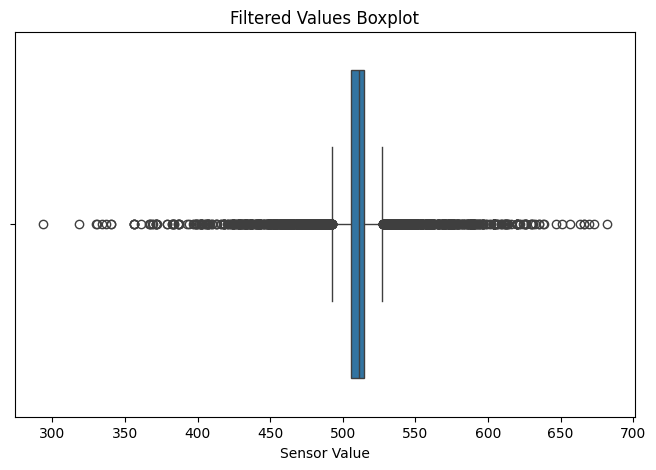

In [45]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['filtered_values'].explode().astype(float))

plt.title('Filtered Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

Envelope Column

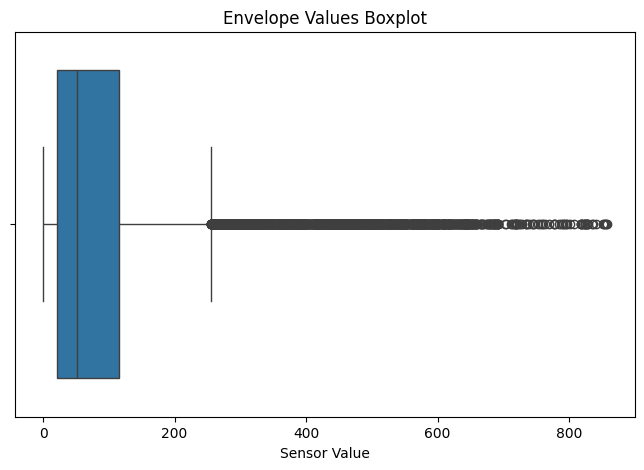

In [46]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['envelope_values'].explode().astype(float))

plt.title('Envelope Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

#### Level by level

In [47]:
# Determine the number of rows and columns for the grid
n_levels = len(level_groups)
cols = 3
rows = math.ceil(n_levels / cols)

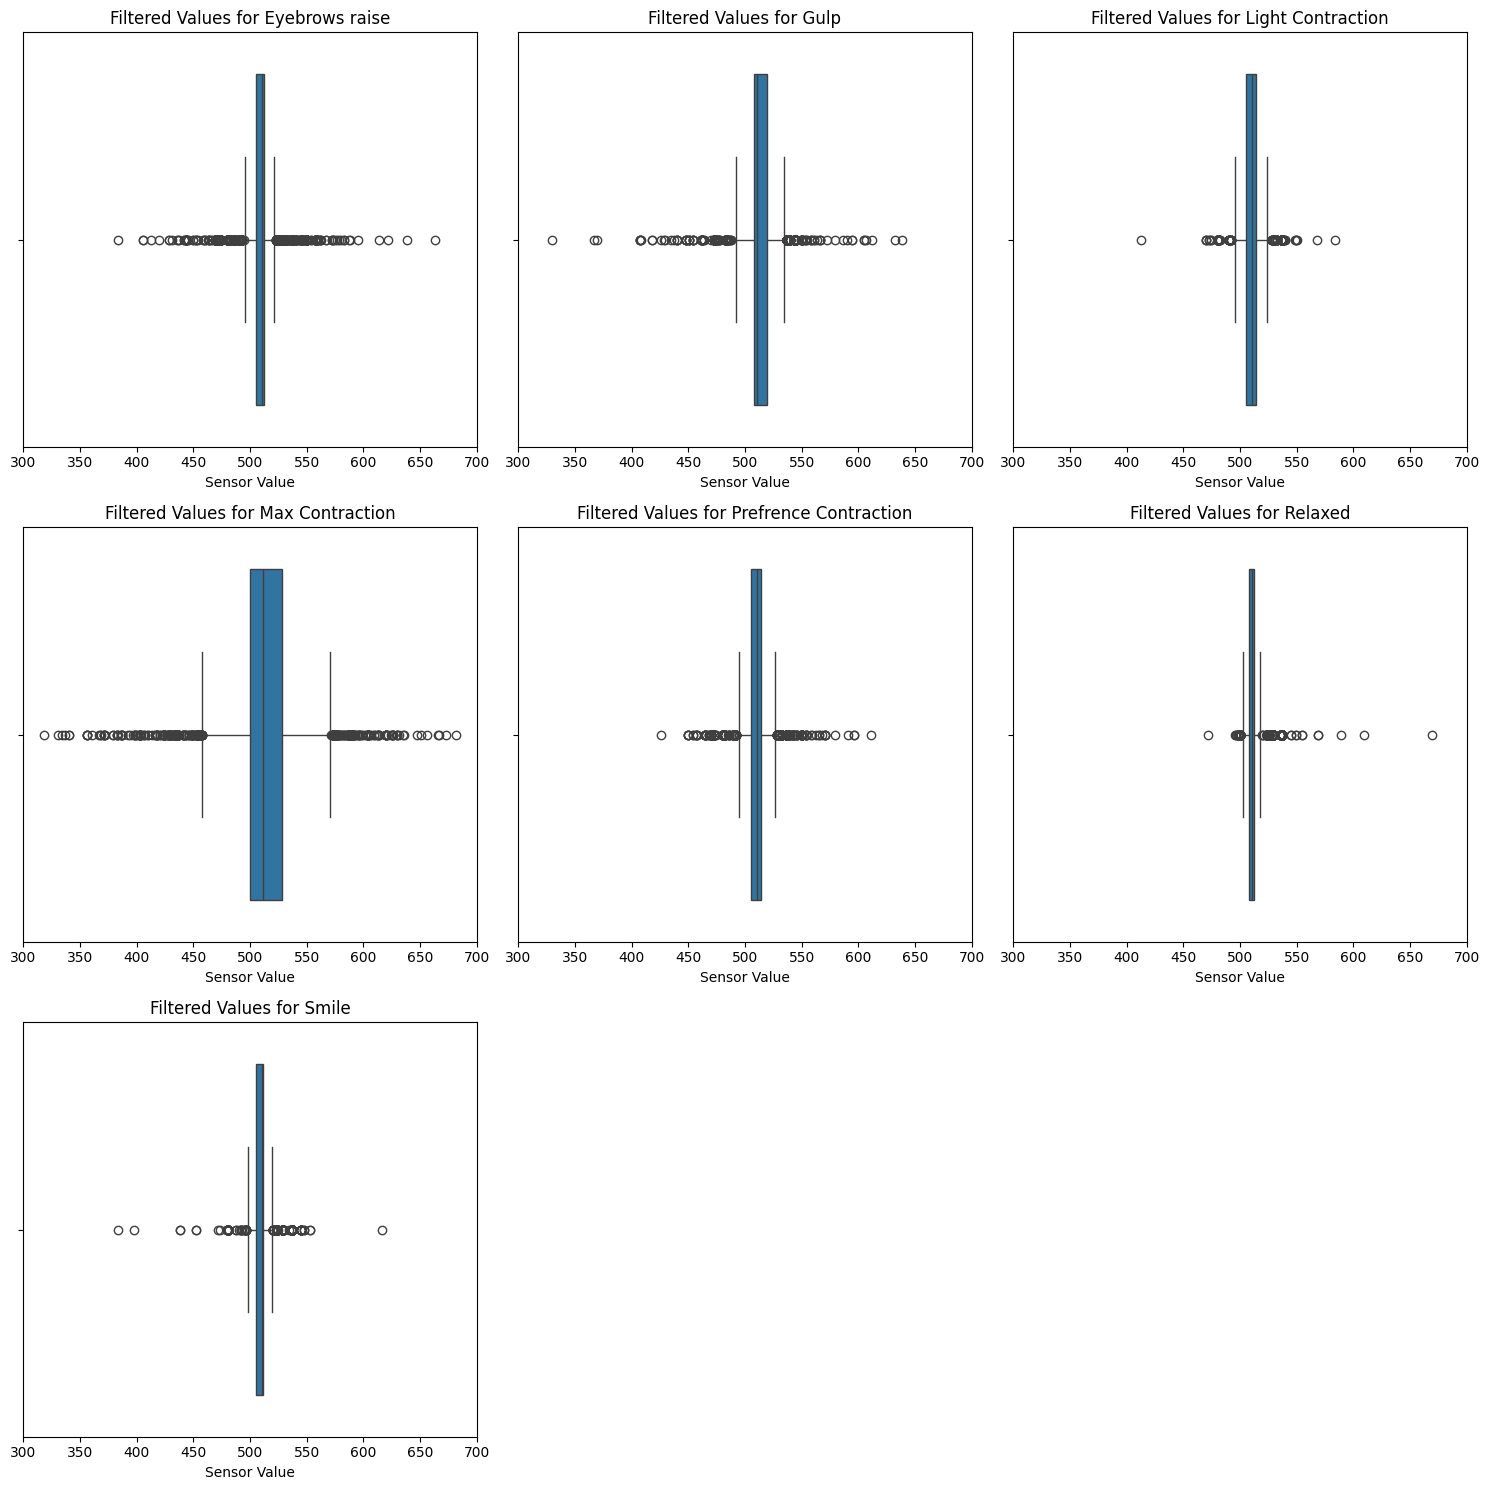

In [48]:
# Create the figure and subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

# Plot each level
for i, level in enumerate(level_groups):
    sns.boxplot(x=level_groups[level]['filtered_values'].explode().astype(float), ax=axes[i])
    axes[i].set_title(f'Filtered Values for {level}')
    axes[i].set_xlabel('Sensor Value')
    axes[i].set_xlim(300, 700)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


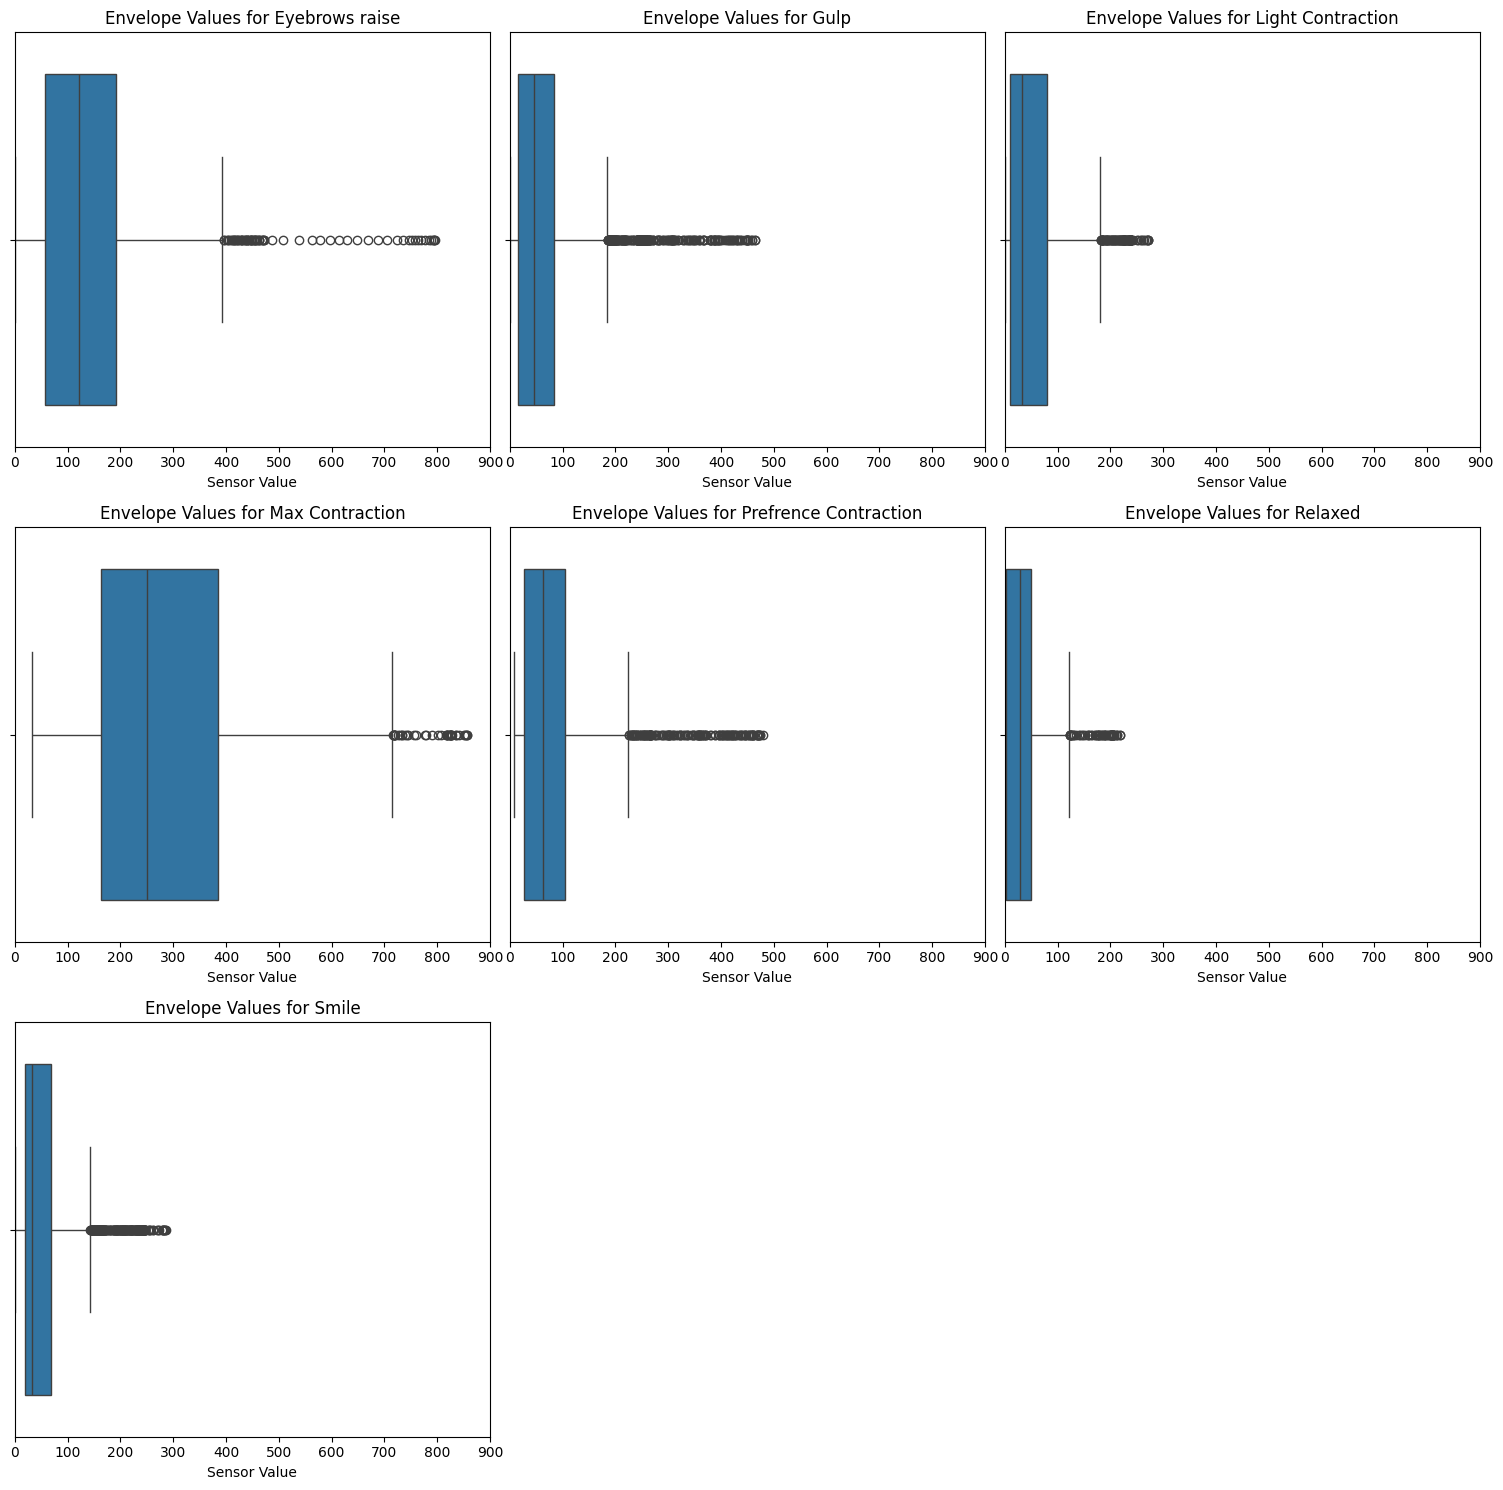

In [49]:
# Create the figure and subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

# Plot each level
for i, level in enumerate(level_groups):
    sns.boxplot(x=level_groups[level]['envelope_values'].explode().astype(float), ax=axes[i])
    axes[i].set_title(f'Envelope Values for {level}')
    axes[i].set_xlabel('Sensor Value')
    axes[i].set_xlim(0, 900)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Envelope values are more distinct across categories than filtered values.

### Outliers - Histogram

#### All values

Filtered Column

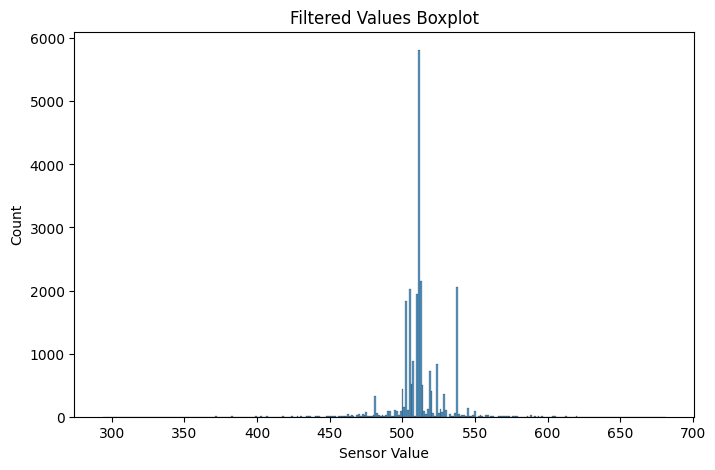

In [50]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.histplot(x=data['filtered_values'].explode().astype(float))
plt.title('Filtered Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

Envelope Column

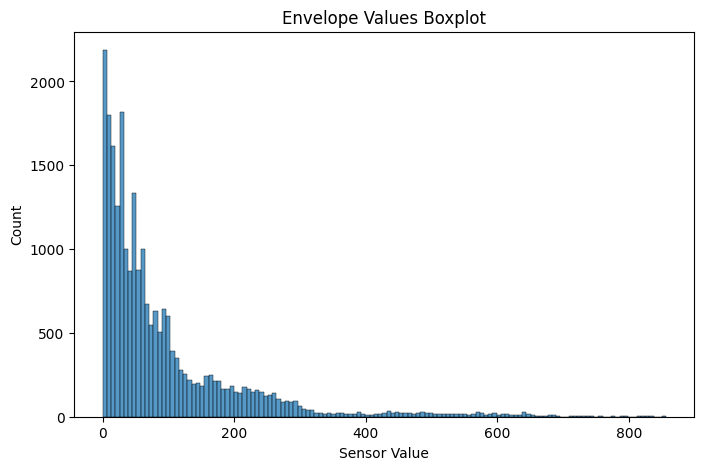

In [51]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.histplot(x=data['envelope_values'].explode().astype(float))

plt.title('Envelope Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

#### Level by level

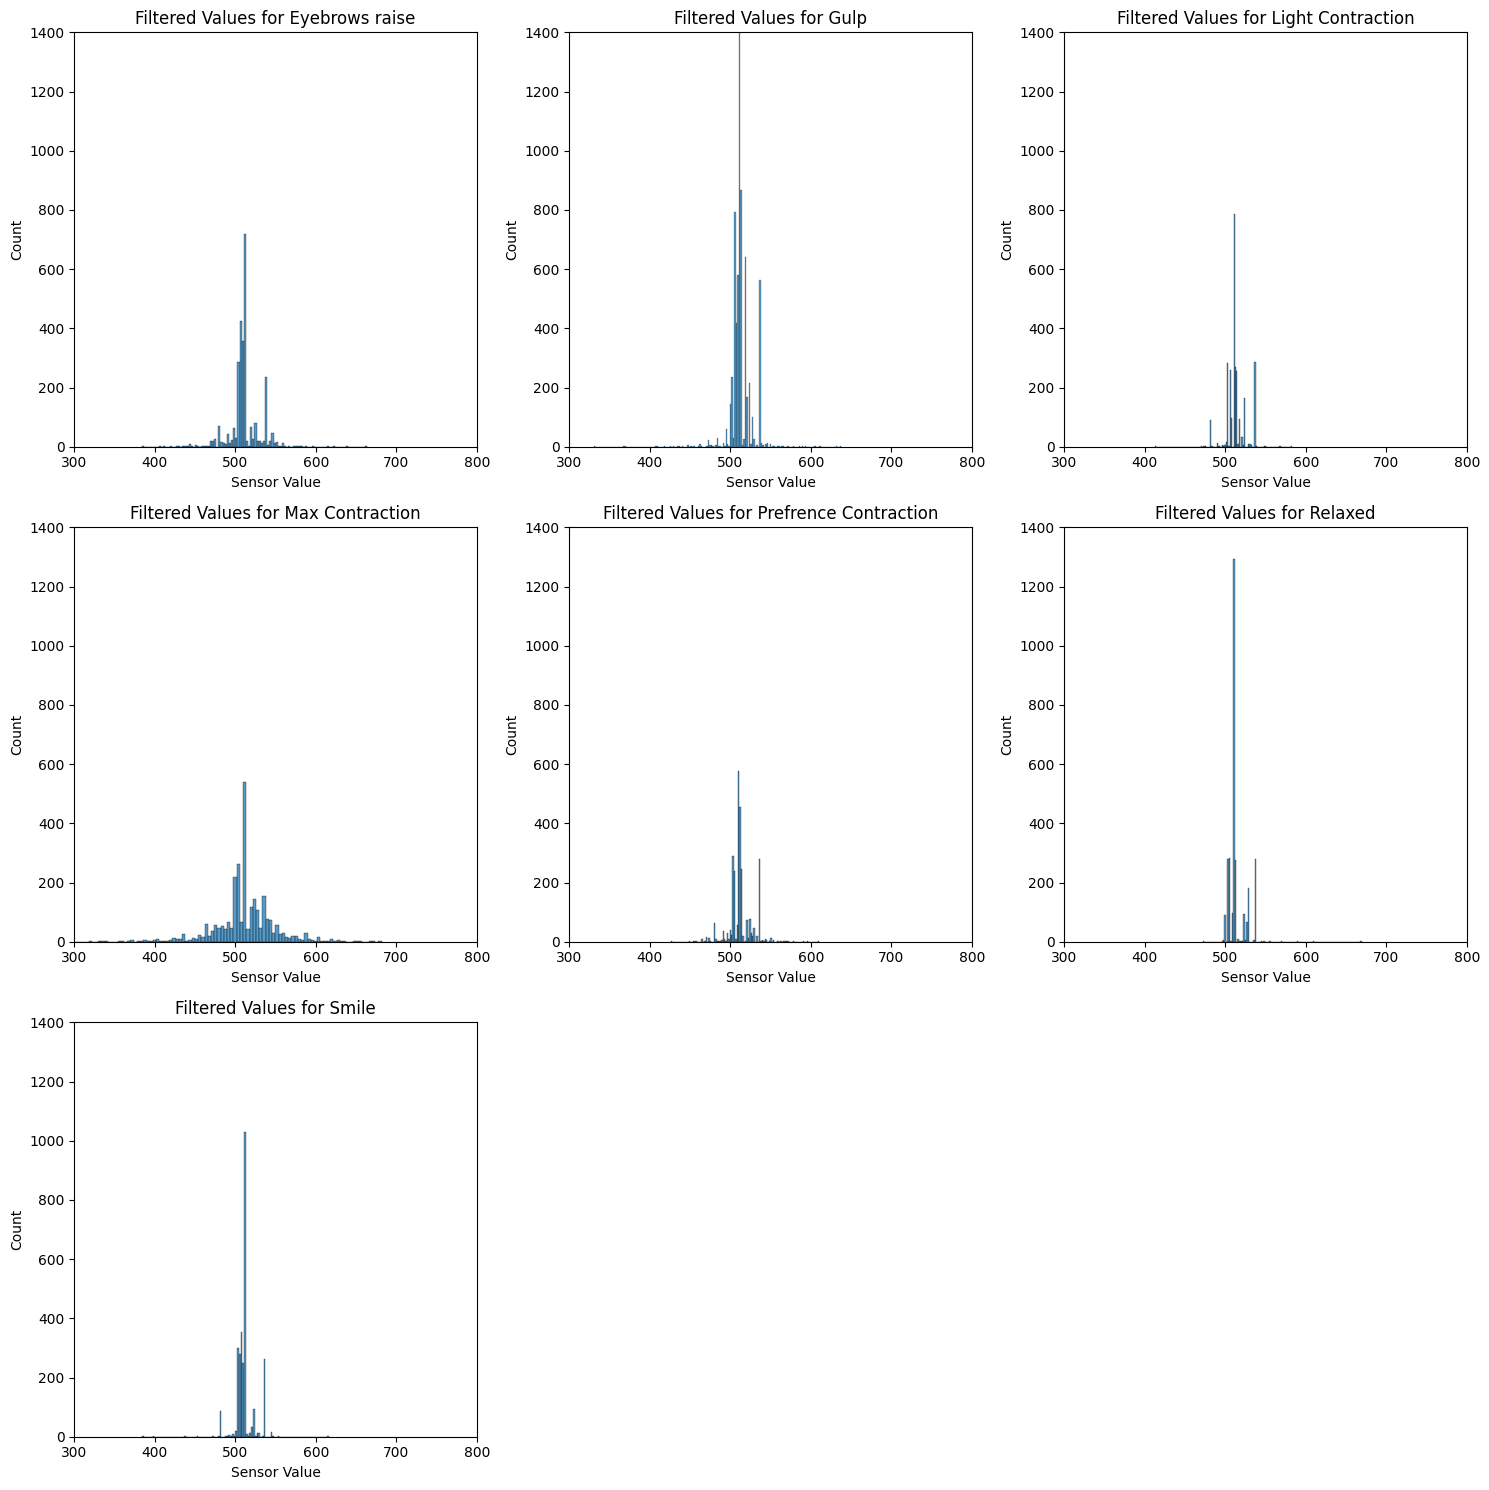

In [52]:
# Create the figure and subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

# Plot each level
for i, level in enumerate(level_groups):
    sns.histplot(x=level_groups[level]['filtered_values'].explode().astype(float), ax=axes[i])
    axes[i].set_title(f'Filtered Values for {level}')
    axes[i].set_xlabel('Sensor Value')
    axes[i].set_xlim(300, 800)
    axes[i].set_ylim(0, 1400)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


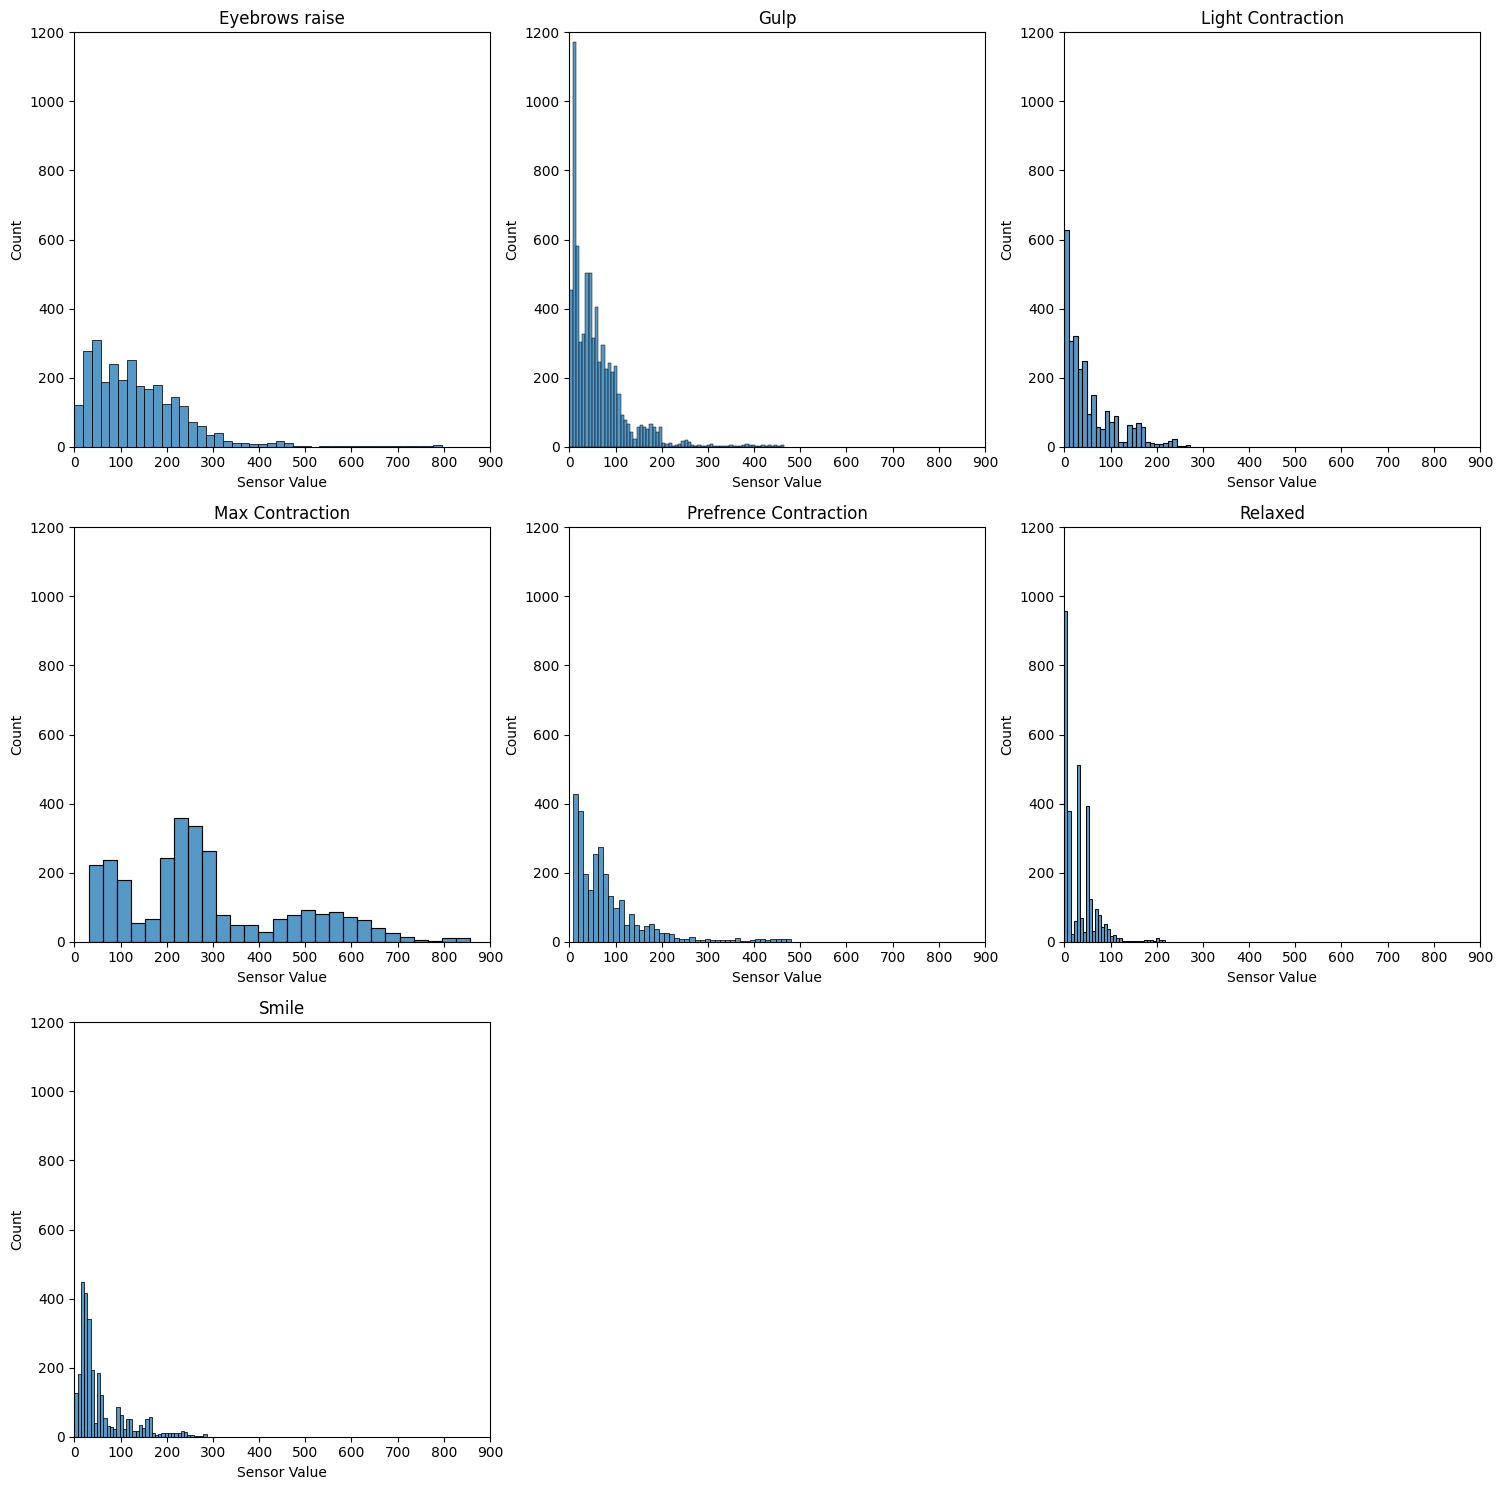

In [53]:
# Create the figure and subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

# Plot each level
for i, level in enumerate(level_groups):
    sns.histplot(x=level_groups[level]['envelope_values'].explode().astype(float), ax=axes[i])
    axes[i].set_title(f'{level}')
    axes[i].set_xlabel('Sensor Value')
    axes[i].set_xlim(0, 900)
    axes[i].set_ylim(0, 1200)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Random Samples

#### User 82

In [54]:
target_id = 82 
user_col = "session_id" 

##### Boxplots

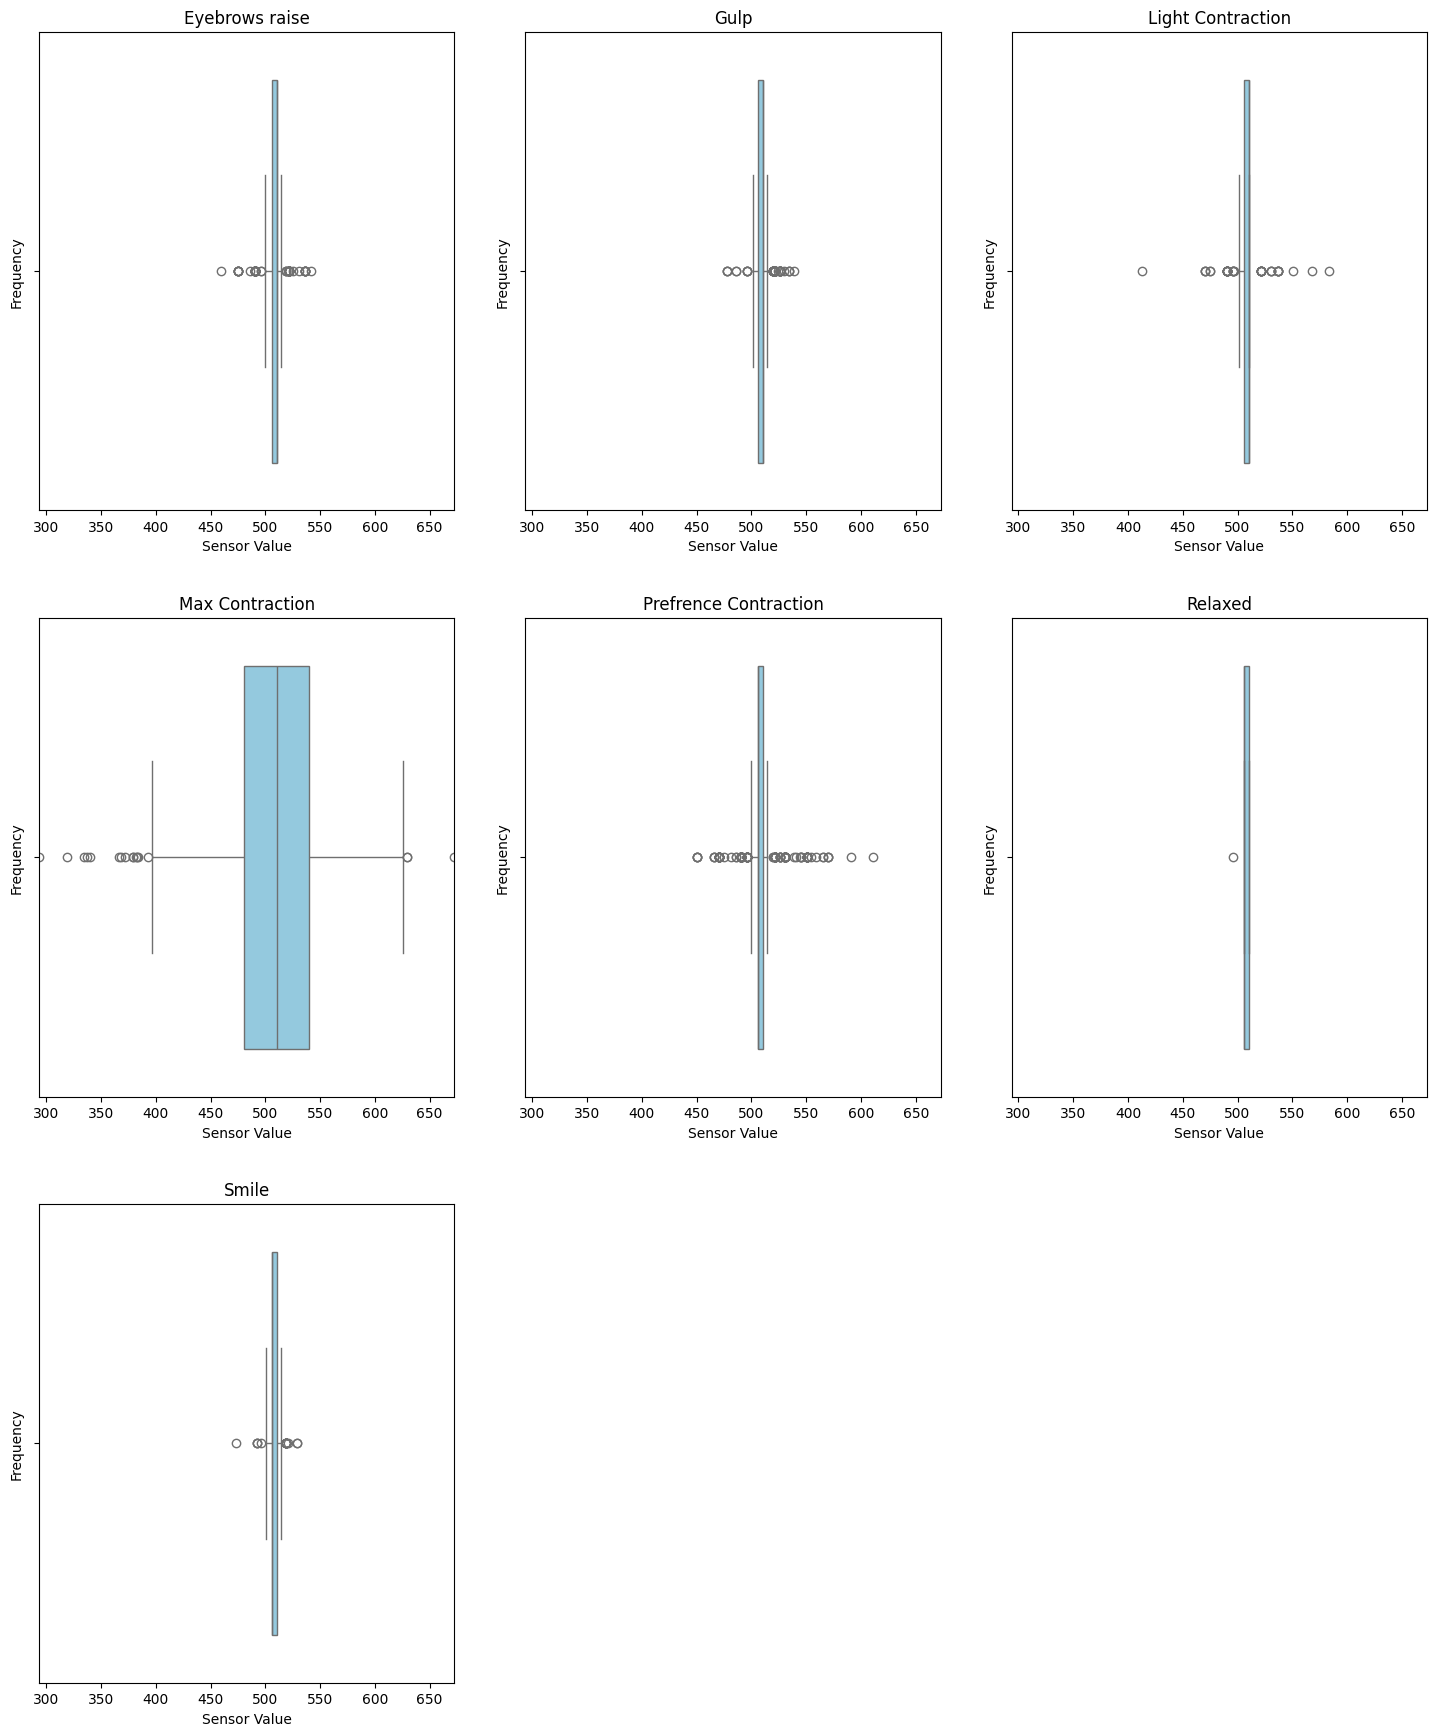

In [55]:
user_data = data[data[user_col] == target_id].copy()

if isinstance(user_data['filtered_values'].iloc[0], str):
    user_data['filtered_values'] = user_data['filtered_values'].apply(ast.literal_eval)

user_level_groups = {level: df for level, df in user_data.groupby('level_number')}

n_levels = len(user_level_groups)

if n_levels == 0:
    print(f"No data found for User ID {target_id}")
else:
    cols = 3
    rows = math.ceil(n_levels / cols)
    
    # Extract all values to find the global min and max for uniform axes
    all_values = user_data['filtered_values'].explode().astype(float)
    global_min = all_values.min()
    global_max = all_values.max()
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
    axes = axes.flatten()
    
    # Plot a histogram for each level
    for i, level in enumerate(user_level_groups):
        plot_data = user_level_groups[level]['filtered_values'].explode().astype(float)
        
        # Plot histogram with 30 bins
        sns.boxplot(x=plot_data, ax=axes[i], color='skyblue')
        
        axes[i].set_title(f'{level}')
        axes[i].set_xlabel('Sensor Value')
        axes[i].set_ylabel('Frequency')
        
        # Set uniform x-axis limits
        axes[i].set_xlim(global_min, global_max)
    
    # Remove any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(pad=3.0)
    plt.show()


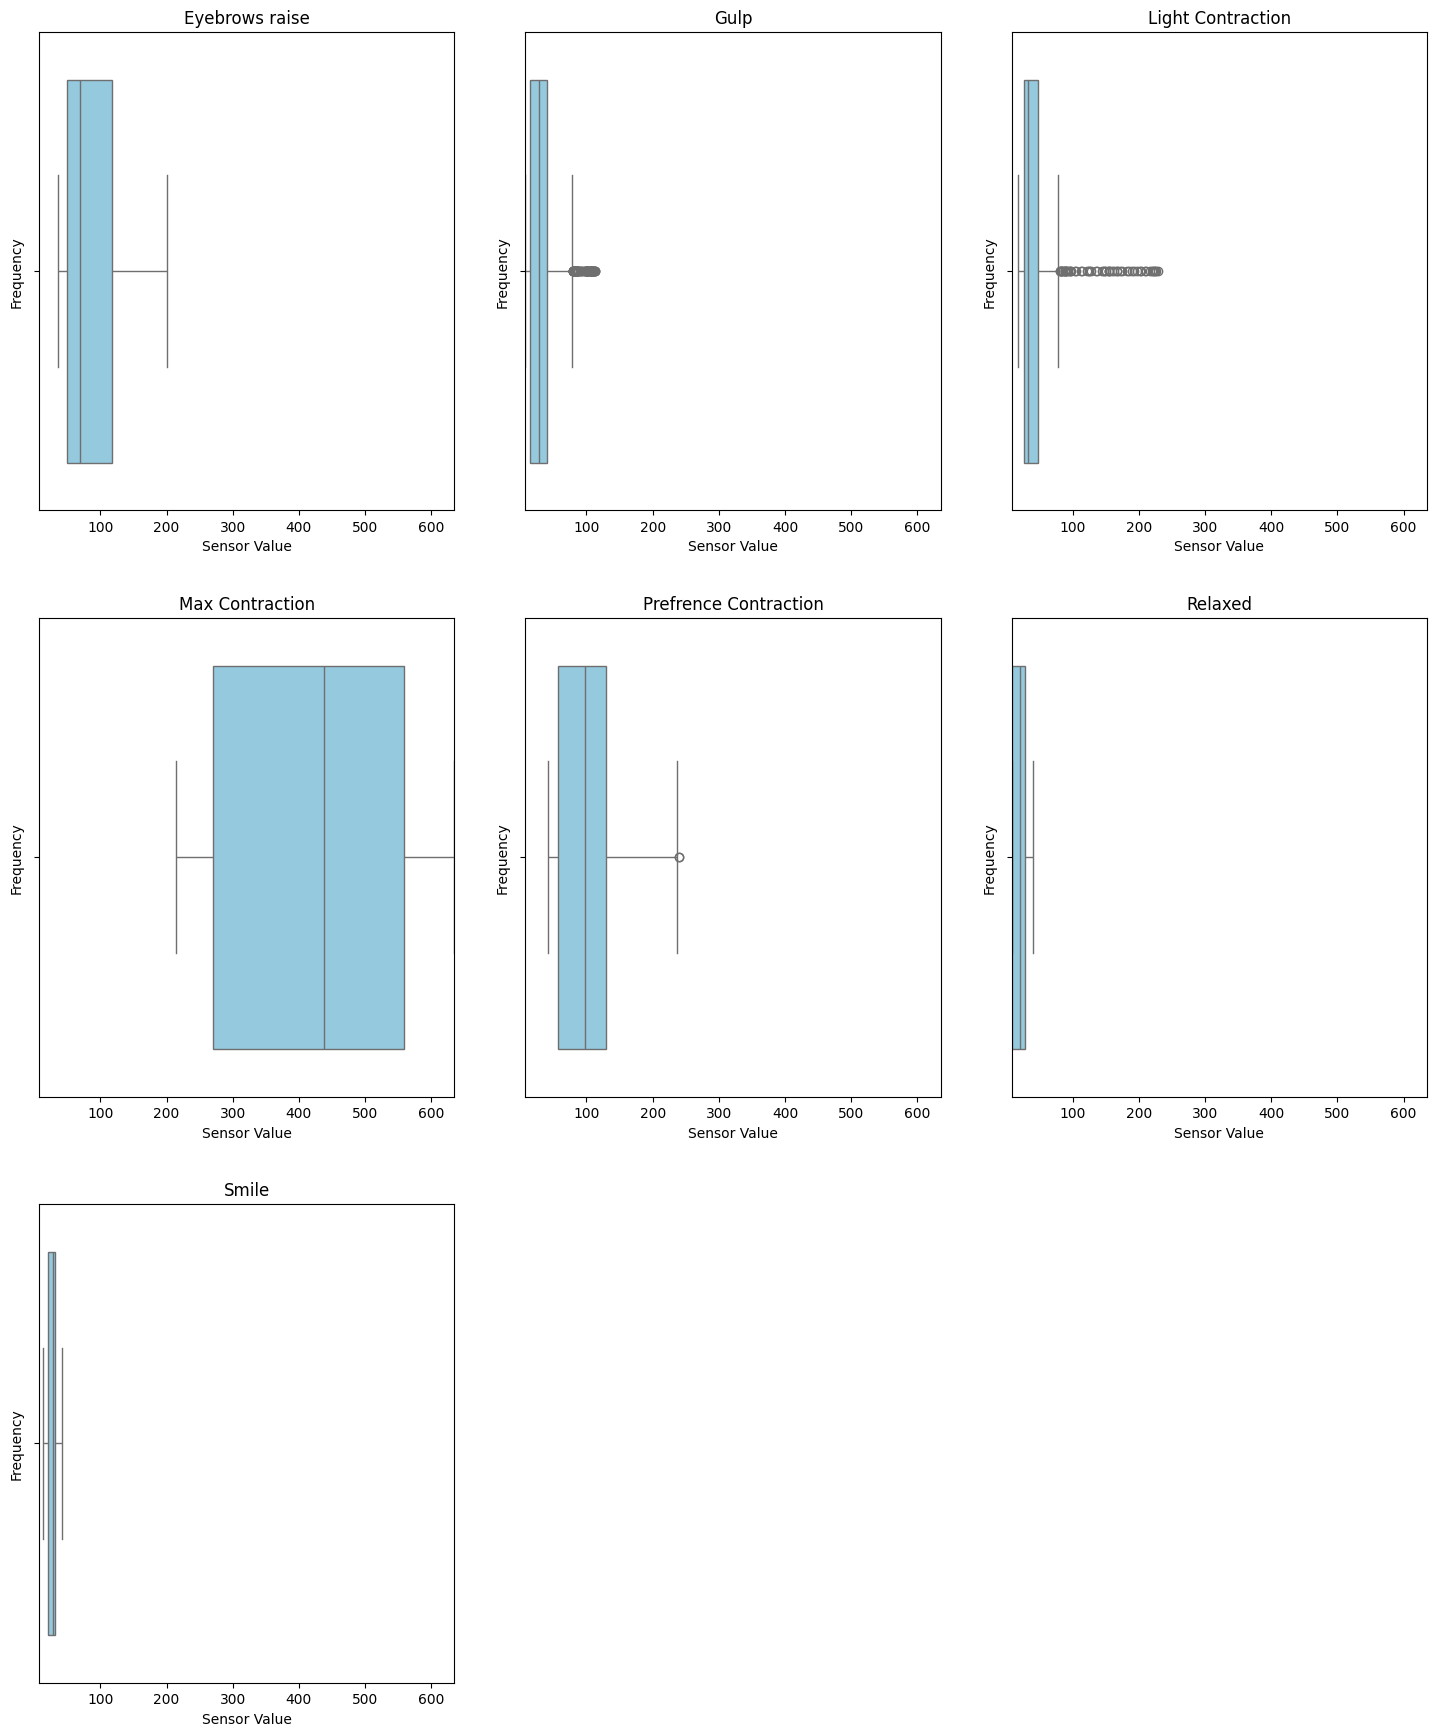

In [56]:
user_data = data[data[user_col] == target_id].copy()

if isinstance(user_data['envelope_values'].iloc[0], str):
    user_data['envelope_values'] = user_data['envelope_values'].apply(ast.literal_eval)

user_level_groups = {level: df for level, df in user_data.groupby('level_number')}

n_levels = len(user_level_groups)

if n_levels == 0:
    print(f"No data found for User ID {target_id}")
else:
    cols = 3
    rows = math.ceil(n_levels / cols)
    
    # Extract all values to find the global min and max for uniform axes
    all_values = user_data['envelope_values'].explode().astype(float)
    global_min = all_values.min()
    global_max = all_values.max()
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
    axes = axes.flatten()
    
    # Plot a histogram for each level
    for i, level in enumerate(user_level_groups):
        plot_data = user_level_groups[level]['envelope_values'].explode().astype(float)
        
        # Plot histogram with 30 bins
        sns.boxplot(x=plot_data, ax=axes[i], color='skyblue')
        
        axes[i].set_title(f'{level}')
        axes[i].set_xlabel('Sensor Value')
        axes[i].set_ylabel('Frequency')
        
        # Set uniform x-axis limits
        axes[i].set_xlim(global_min, global_max)
    
    # Remove any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(pad=3.0)
    plt.show()


##### Histograms

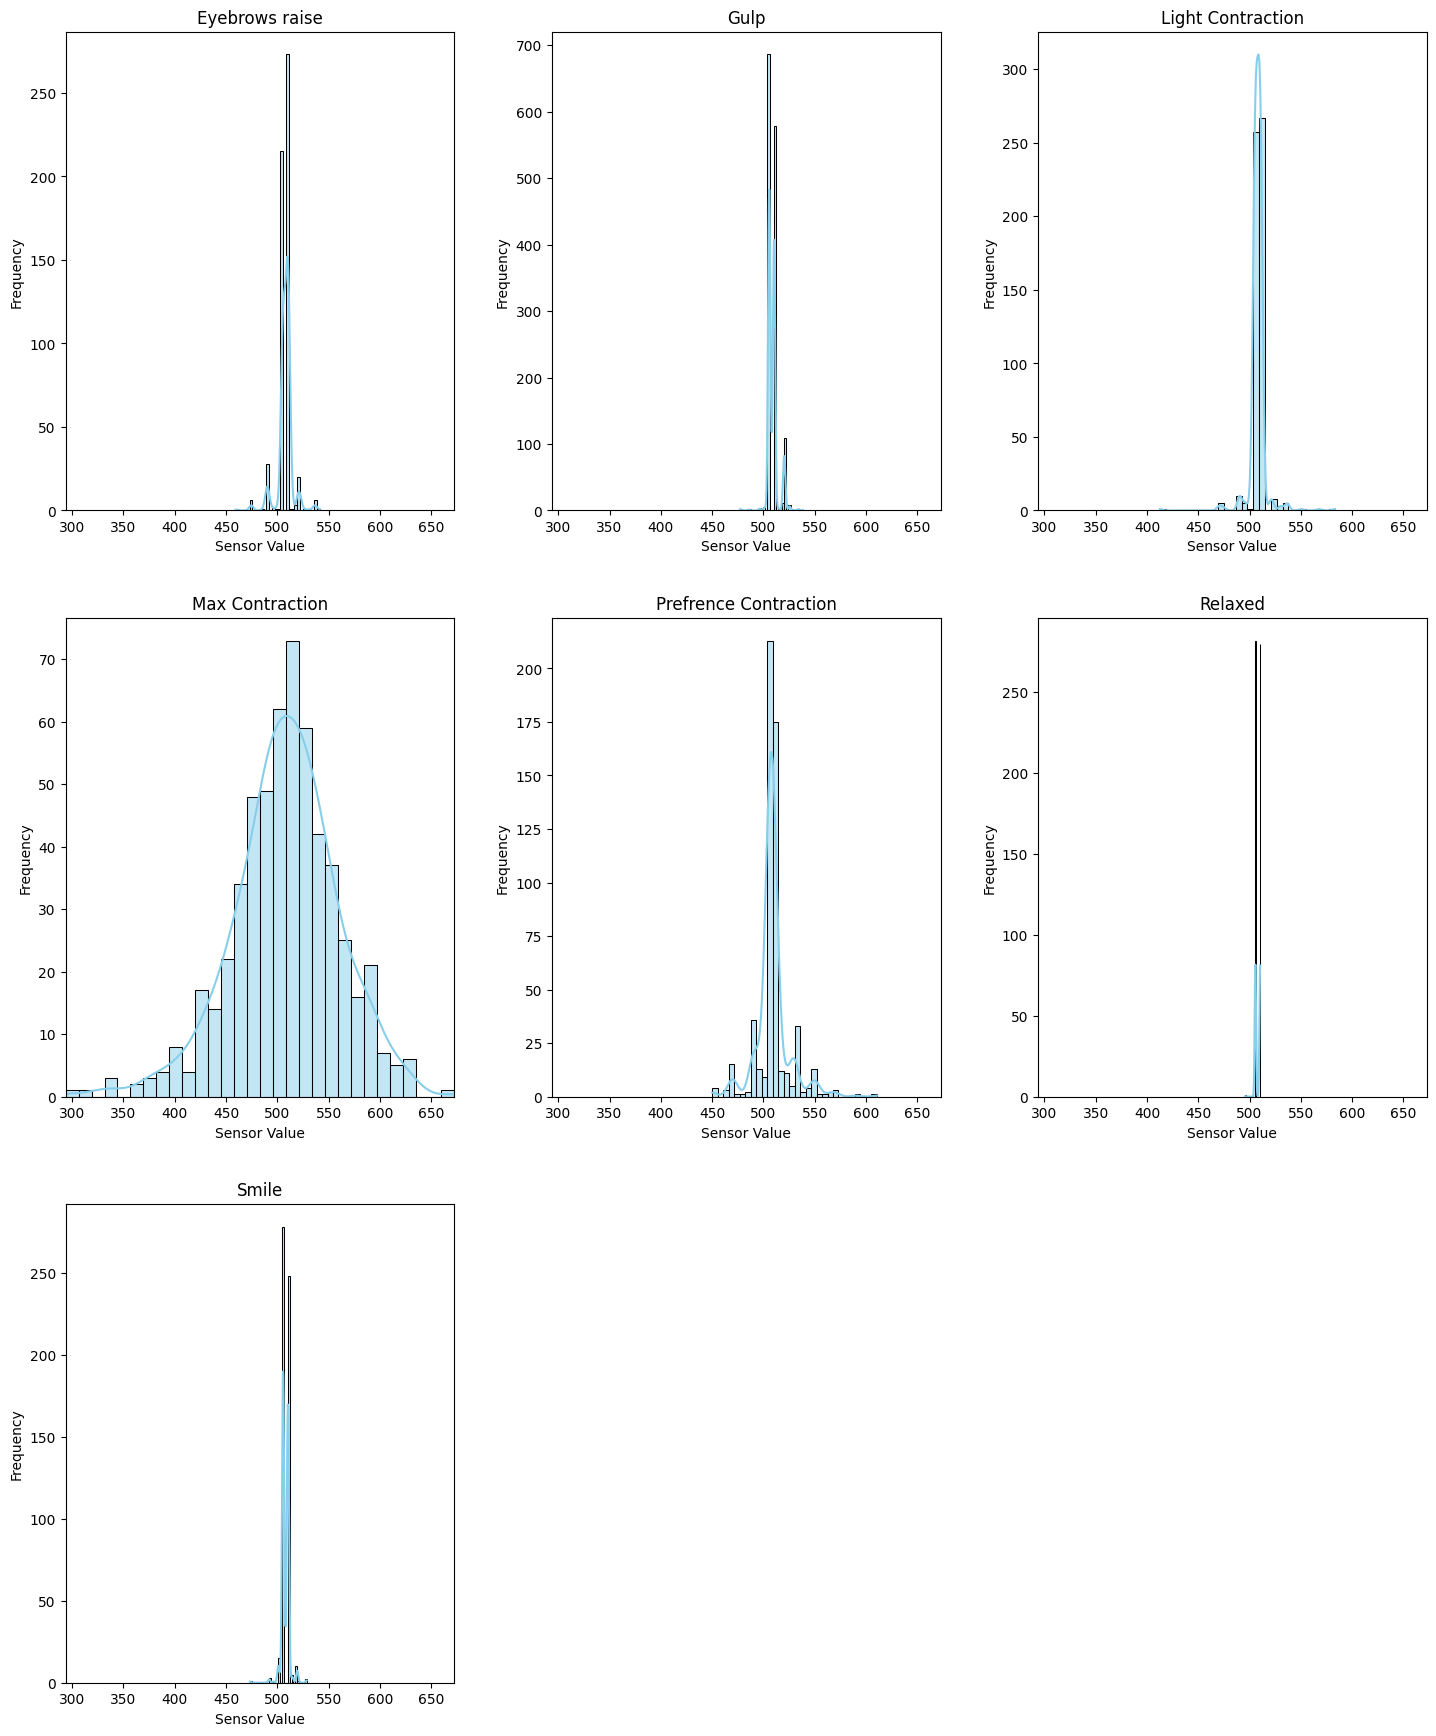

In [57]:
user_data = data[data[user_col] == target_id].copy()

if isinstance(user_data['filtered_values'].iloc[0], str):
    user_data['filtered_values'] = user_data['filtered_values'].apply(ast.literal_eval)

user_level_groups = {level: df for level, df in user_data.groupby('level_number')}

n_levels = len(user_level_groups)

if n_levels == 0:
    print(f"No data found for User ID {target_id}")
else:
    cols = 3
    rows = math.ceil(n_levels / cols)
    
    # Extract all values to find the global min and max for uniform axes
    all_values = user_data['filtered_values'].explode().astype(float)
    global_min = all_values.min()
    global_max = all_values.max()
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
    axes = axes.flatten()
    
    # Plot a histogram for each level
    for i, level in enumerate(user_level_groups):
        plot_data = user_level_groups[level]['filtered_values'].explode().astype(float)
        
        # Plot histogram with 30 bins
        sns.histplot(x=plot_data, ax=axes[i], bins=30, kde=True, color='skyblue')
        
        axes[i].set_title(f'{level}')
        axes[i].set_xlabel('Sensor Value')
        axes[i].set_ylabel('Frequency')
        
        # Set uniform x-axis limits
        axes[i].set_xlim(global_min, global_max)
    
    # Remove any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(pad=3.0)
    plt.show()


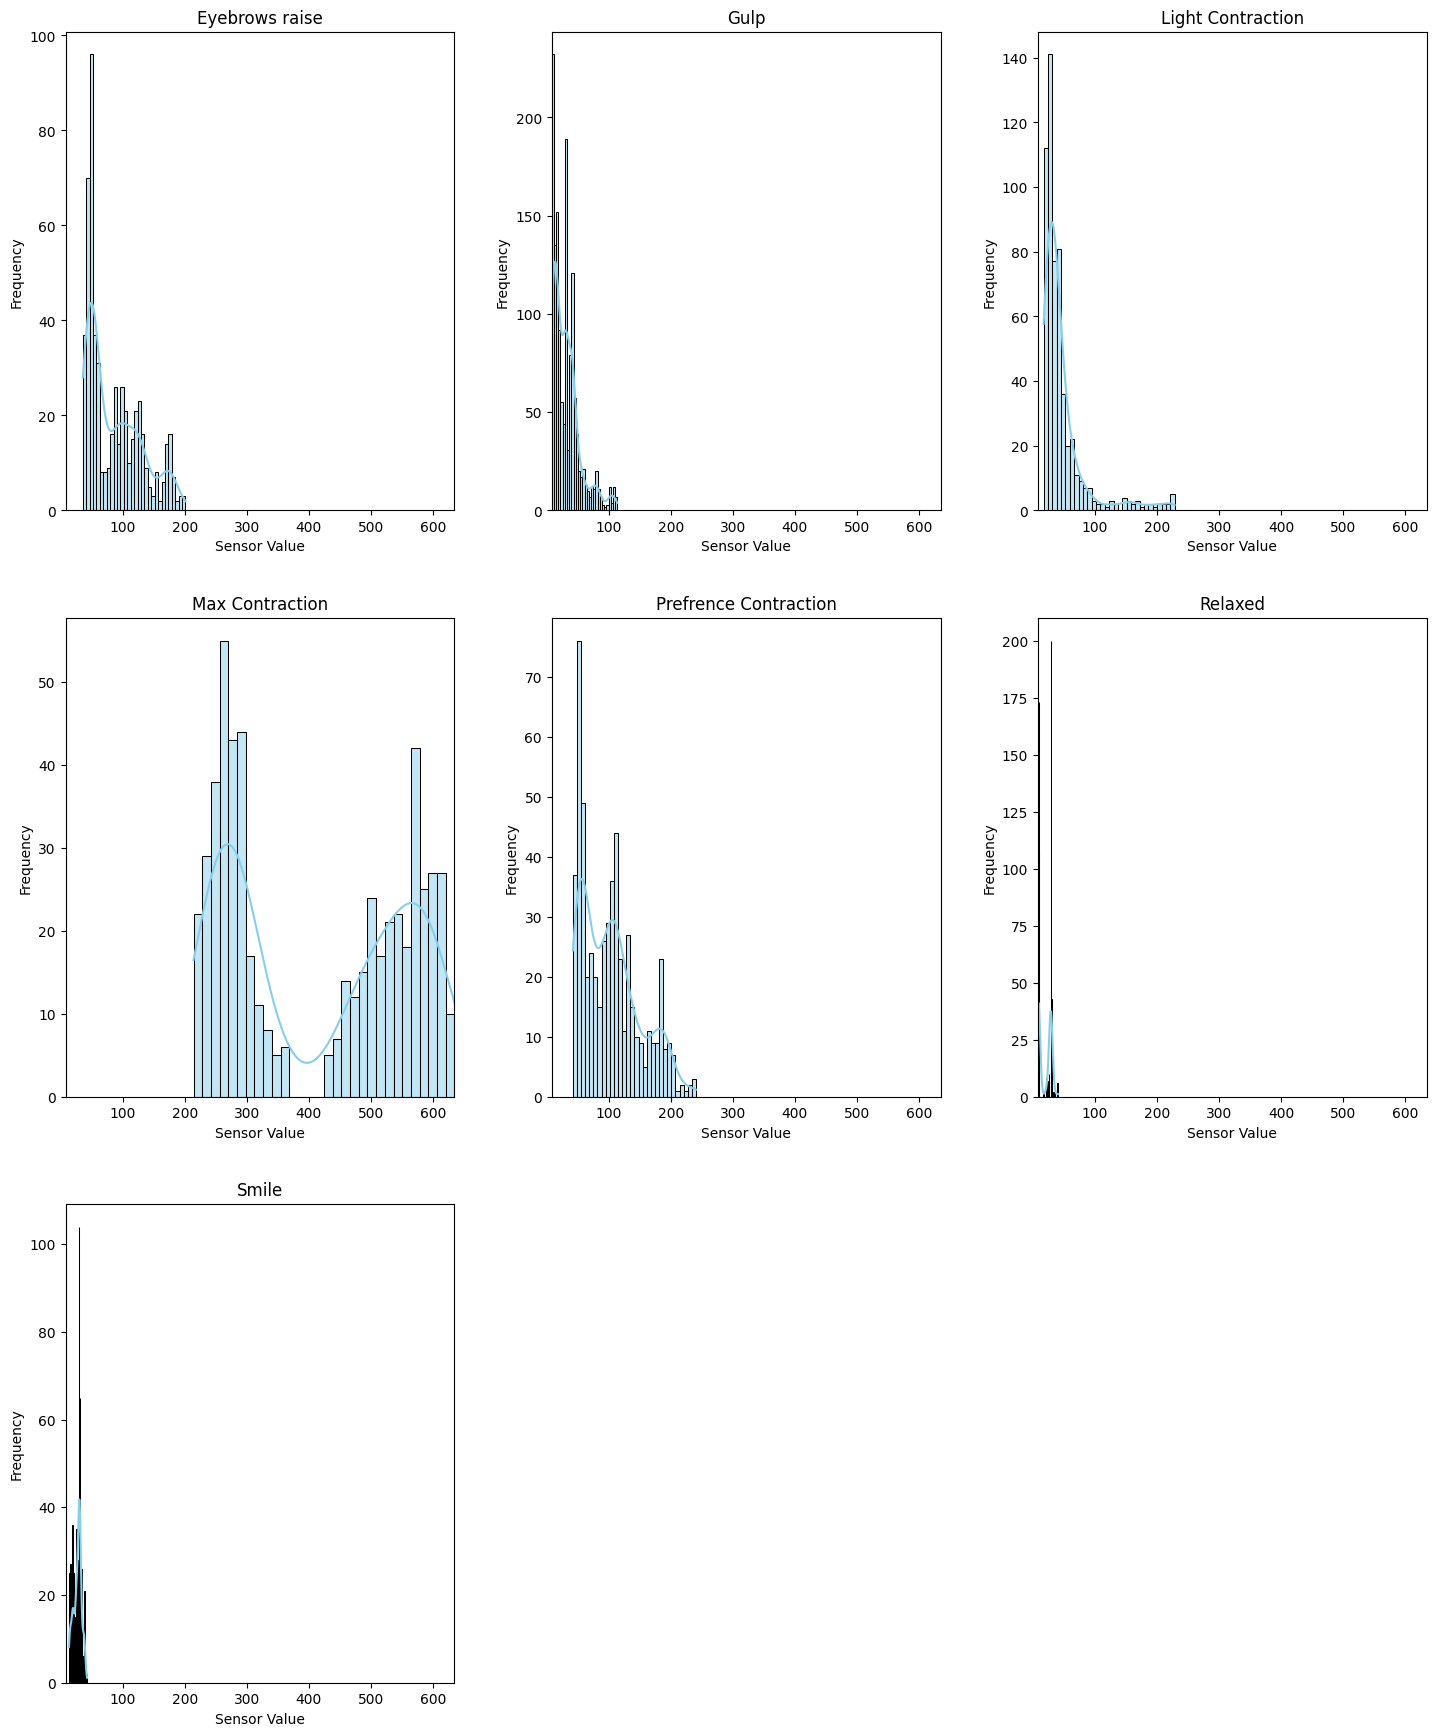

In [58]:
user_data = data[data[user_col] == target_id].copy()

if isinstance(user_data['envelope_values'].iloc[0], str):
    user_data['envelope_values'] = user_data['envelope_values'].apply(ast.literal_eval)

user_level_groups = {level: df for level, df in user_data.groupby('level_number')}

n_levels = len(user_level_groups)

if n_levels == 0:
    print(f"No data found for User ID {target_id}")
else:
    cols = 3
    rows = math.ceil(n_levels / cols)
    
    # Extract all values to find the global min and max for uniform axes
    all_values = user_data['envelope_values'].explode().astype(float)
    global_min = all_values.min()
    global_max = all_values.max()
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
    axes = axes.flatten()
    
    # Plot a histogram for each level
    for i, level in enumerate(user_level_groups):
        plot_data = user_level_groups[level]['envelope_values'].explode().astype(float)
        
        # Plot histogram with 30 bins
        sns.histplot(x=plot_data, ax=axes[i], bins=30, kde=True, color='skyblue')
        
        axes[i].set_title(f'{level}')
        axes[i].set_xlabel('Sensor Value')
        axes[i].set_ylabel('Frequency')
        
        # Set uniform x-axis limits
        axes[i].set_xlim(global_min, global_max)
    
    # Remove any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(pad=3.0)
    plt.show()


#### User 372

In [59]:
target_id = 372 
user_col = "session_id" 

##### Boxplots

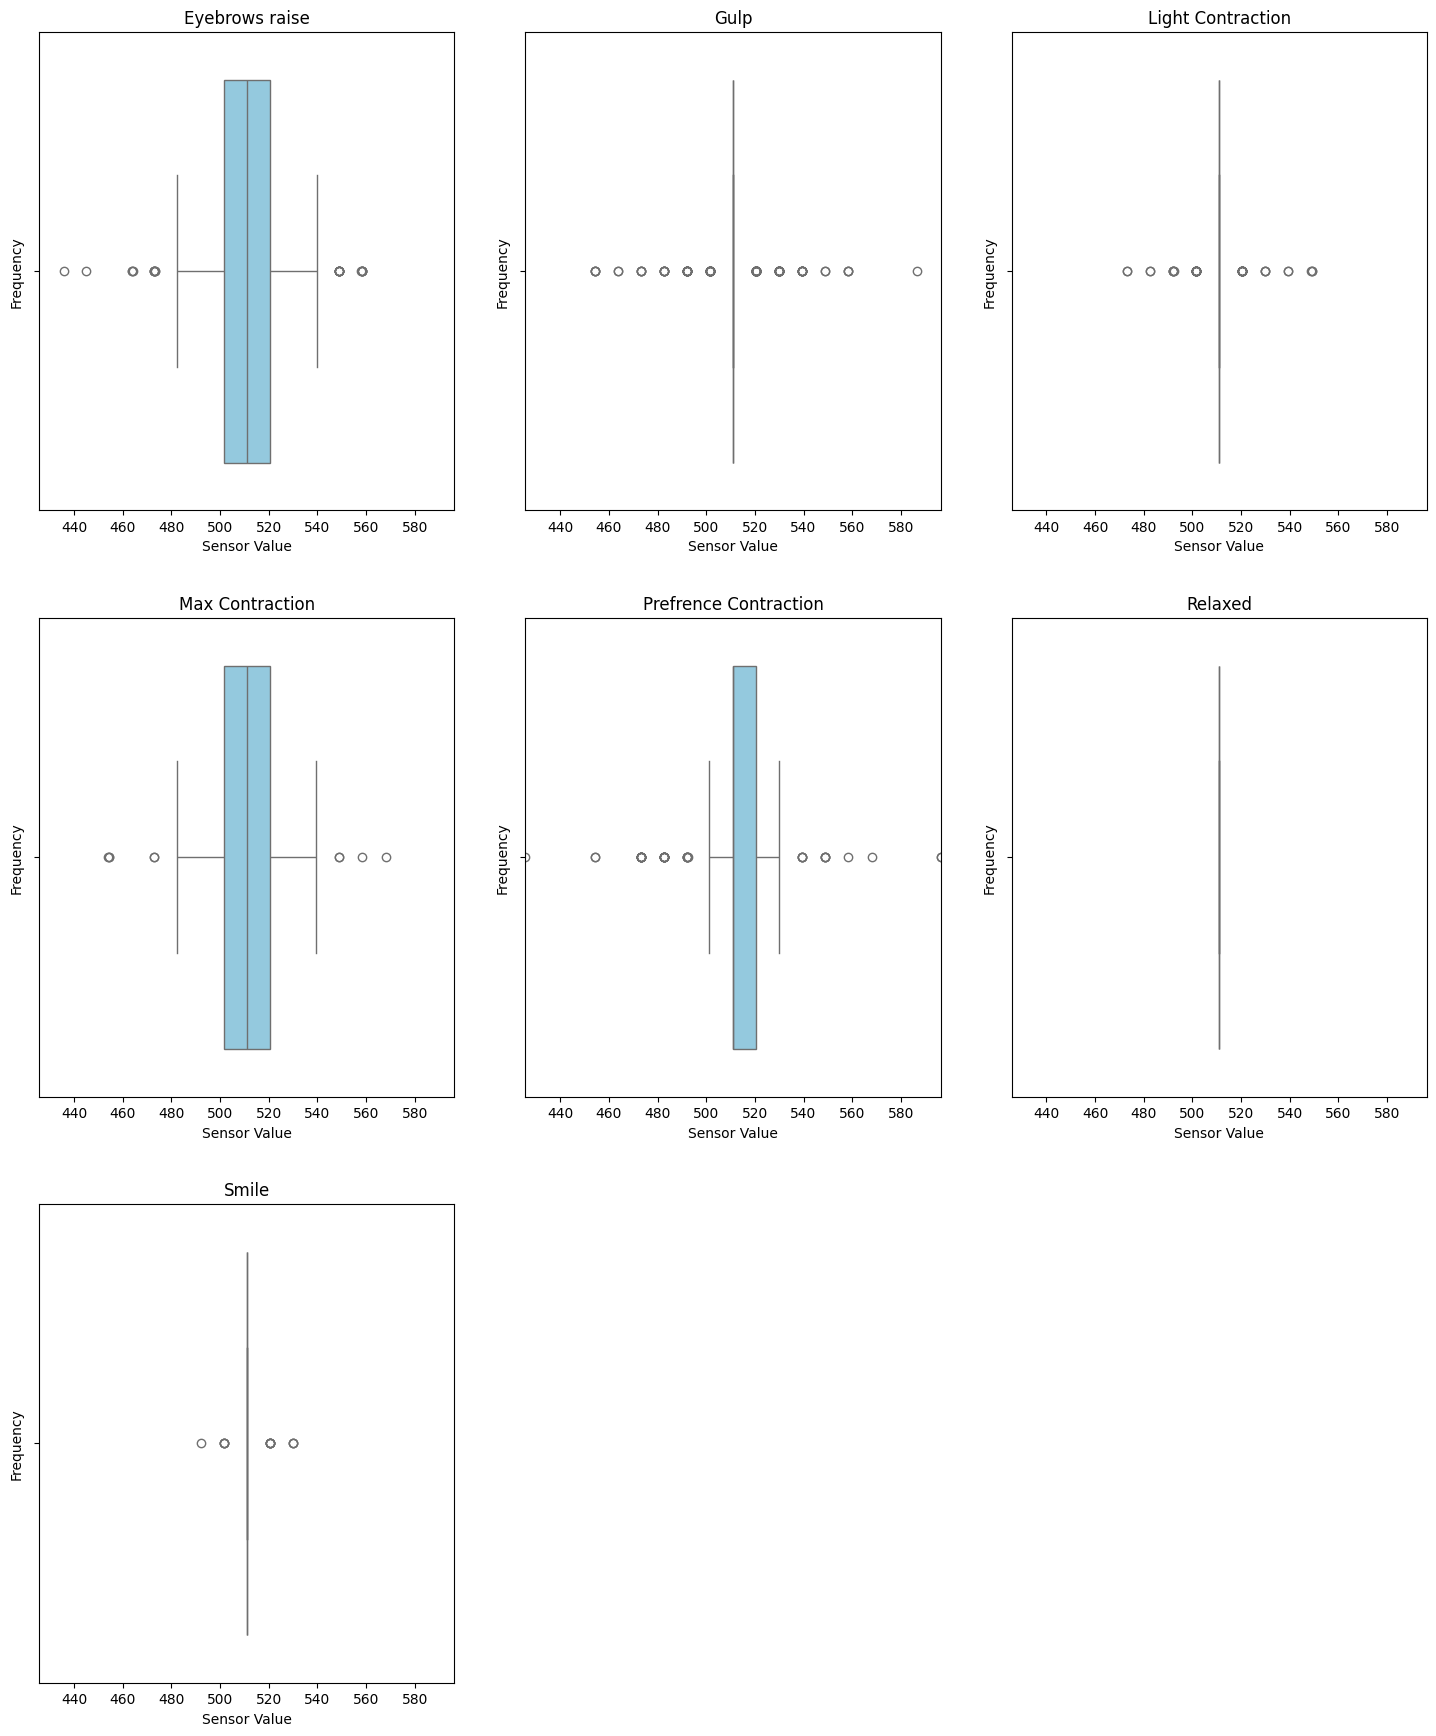

In [60]:
user_data = data[data[user_col] == target_id].copy()

if isinstance(user_data['filtered_values'].iloc[0], str):
    user_data['filtered_values'] = user_data['filtered_values'].apply(ast.literal_eval)

user_level_groups = {level: df for level, df in user_data.groupby('level_number')}

n_levels = len(user_level_groups)

if n_levels == 0:
    print(f"No data found for User ID {target_id}")
else:
    cols = 3
    rows = math.ceil(n_levels / cols)
    
    # Extract all values to find the global min and max for uniform axes
    all_values = user_data['filtered_values'].explode().astype(float)
    global_min = all_values.min()
    global_max = all_values.max()
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
    axes = axes.flatten()
    
    # Plot a histogram for each level
    for i, level in enumerate(user_level_groups):
        plot_data = user_level_groups[level]['filtered_values'].explode().astype(float)
        
        # Plot histogram with 30 bins
        sns.boxplot(x=plot_data, ax=axes[i], color='skyblue')
        
        axes[i].set_title(f'{level}')
        axes[i].set_xlabel('Sensor Value')
        axes[i].set_ylabel('Frequency')
        
        # Set uniform x-axis limits
        axes[i].set_xlim(global_min, global_max)
    
    # Remove any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(pad=3.0)
    plt.show()


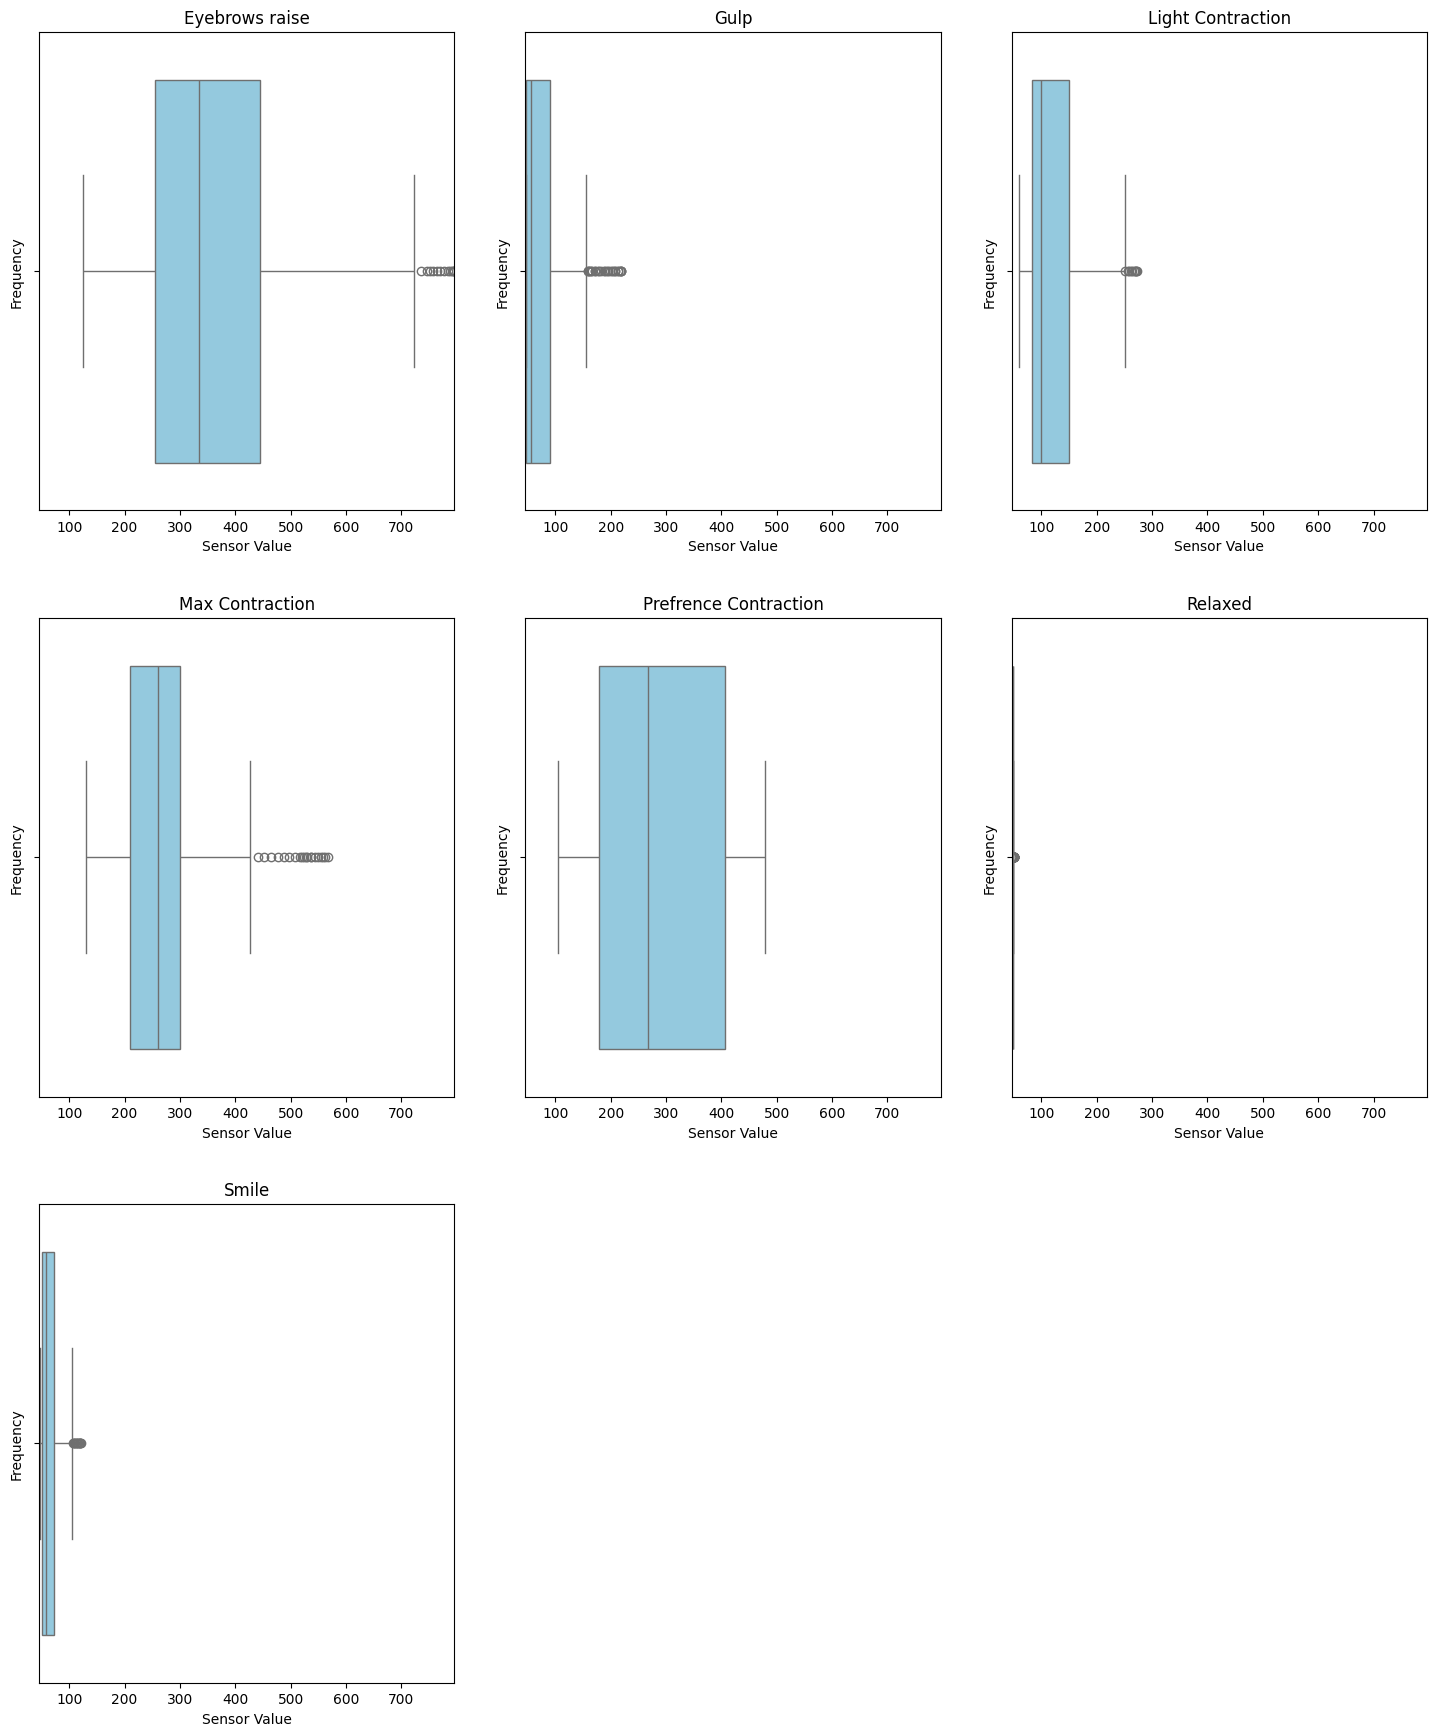

In [61]:
user_data = data[data[user_col] == target_id].copy()

if isinstance(user_data['envelope_values'].iloc[0], str):
    user_data['envelope_values'] = user_data['envelope_values'].apply(ast.literal_eval)

user_level_groups = {level: df for level, df in user_data.groupby('level_number')}

n_levels = len(user_level_groups)

if n_levels == 0:
    print(f"No data found for User ID {target_id}")
else:
    cols = 3
    rows = math.ceil(n_levels / cols)
    
    # Extract all values to find the global min and max for uniform axes
    all_values = user_data['envelope_values'].explode().astype(float)
    global_min = all_values.min()
    global_max = all_values.max()
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
    axes = axes.flatten()
    
    # Plot a histogram for each level
    for i, level in enumerate(user_level_groups):
        plot_data = user_level_groups[level]['envelope_values'].explode().astype(float)
        
        # Plot histogram with 30 bins
        sns.boxplot(x=plot_data, ax=axes[i], color='skyblue')
        
        axes[i].set_title(f'{level}')
        axes[i].set_xlabel('Sensor Value')
        axes[i].set_ylabel('Frequency')
        
        # Set uniform x-axis limits
        axes[i].set_xlim(global_min, global_max)
    
    # Remove any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(pad=3.0)
    plt.show()


##### Histograms

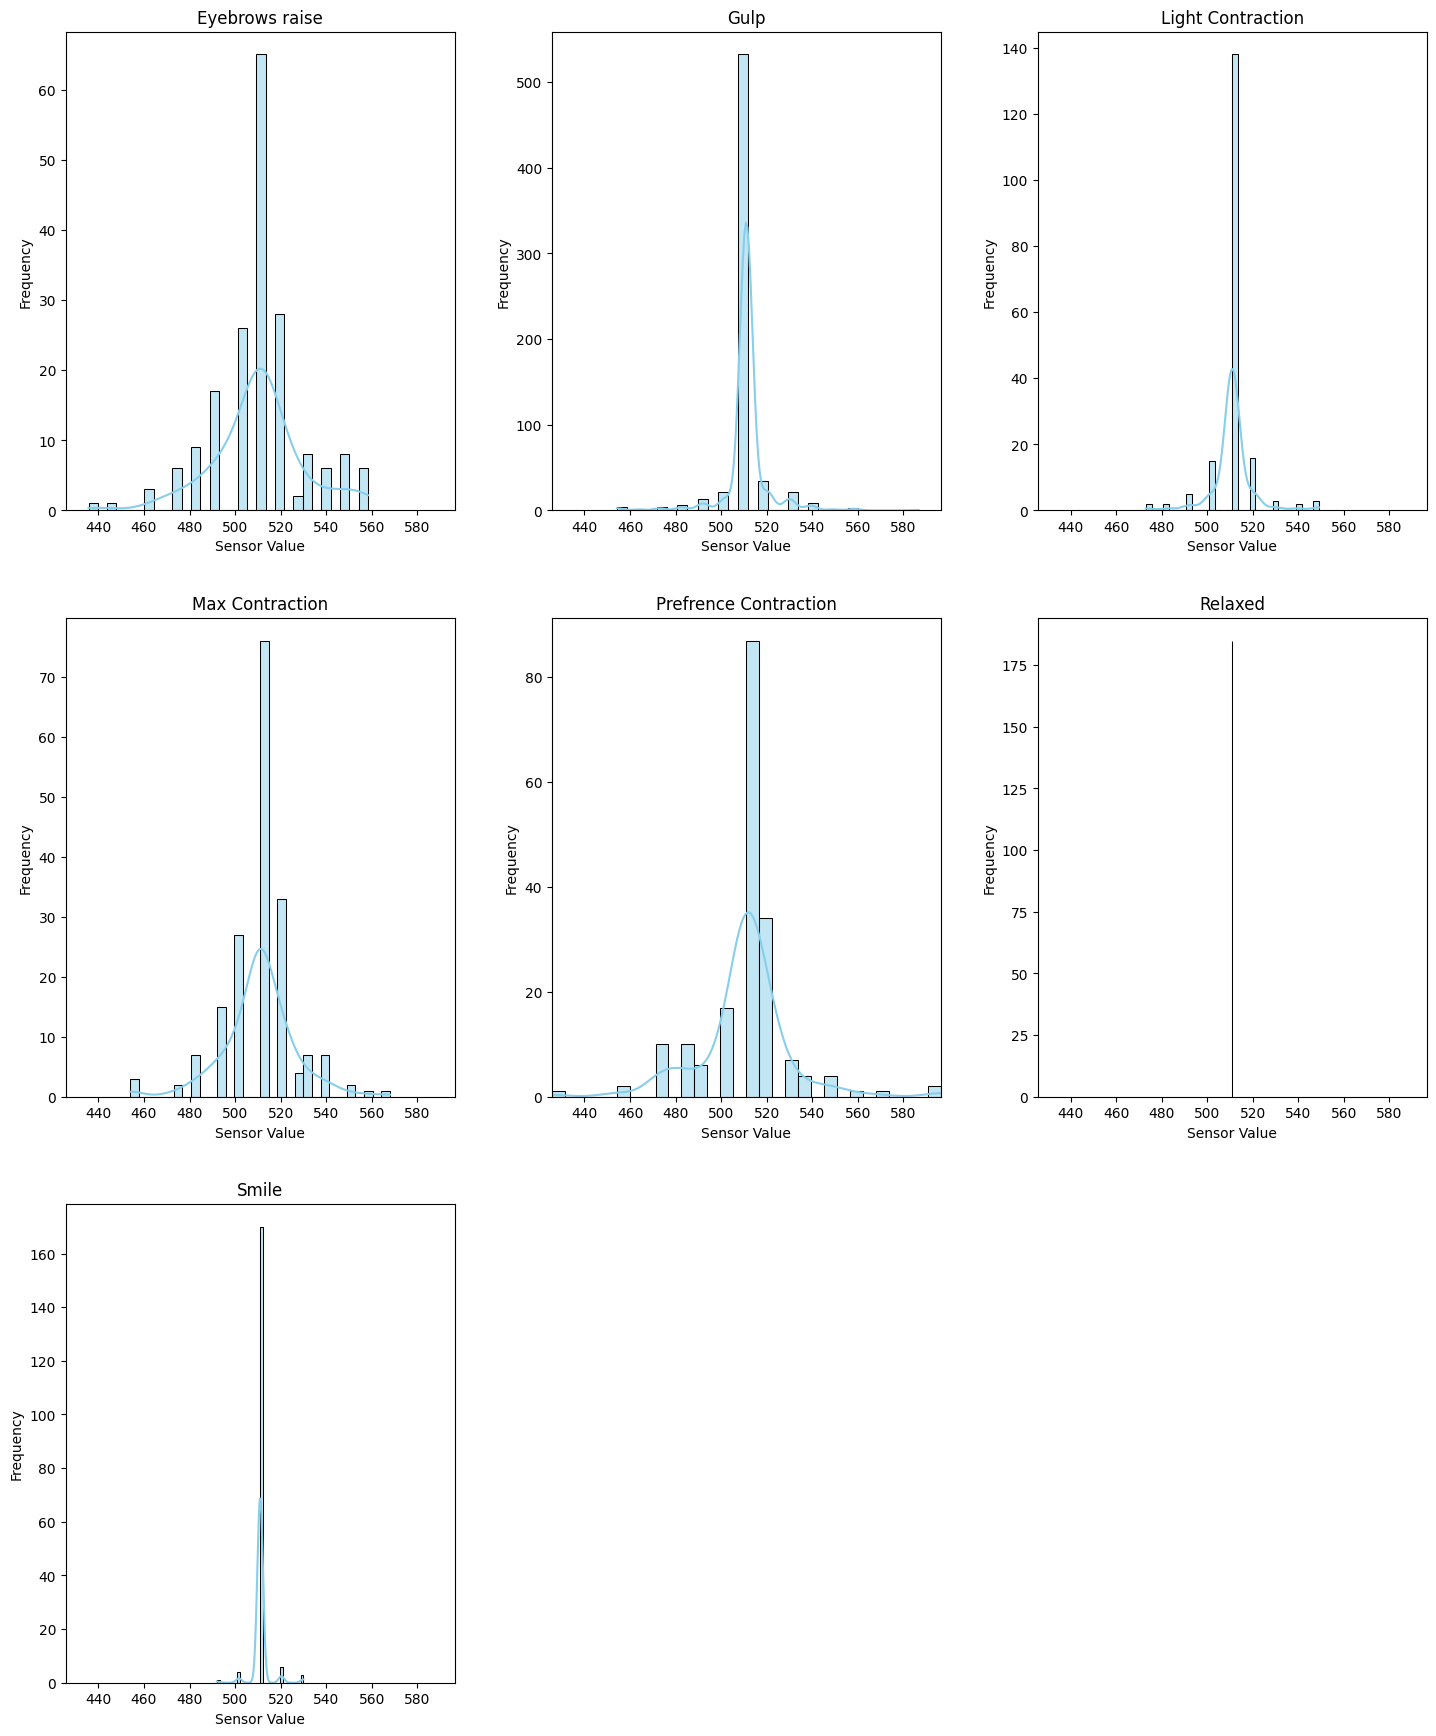

In [62]:
user_data = data[data[user_col] == target_id].copy()

if isinstance(user_data['filtered_values'].iloc[0], str):
    user_data['filtered_values'] = user_data['filtered_values'].apply(ast.literal_eval)

user_level_groups = {level: df for level, df in user_data.groupby('level_number')}

n_levels = len(user_level_groups)

if n_levels == 0:
    print(f"No data found for User ID {target_id}")
else:
    cols = 3
    rows = math.ceil(n_levels / cols)
    
    # Extract all values to find the global min and max for uniform axes
    all_values = user_data['filtered_values'].explode().astype(float)
    global_min = all_values.min()
    global_max = all_values.max()
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
    axes = axes.flatten()
    
    # Plot a histogram for each level
    for i, level in enumerate(user_level_groups):
        plot_data = user_level_groups[level]['filtered_values'].explode().astype(float)
        
        # Plot histogram with 30 bins
        sns.histplot(x=plot_data, ax=axes[i], bins=30, kde=True, color='skyblue')
        
        axes[i].set_title(f'{level}')
        axes[i].set_xlabel('Sensor Value')
        axes[i].set_ylabel('Frequency')
        
        # Set uniform x-axis limits
        axes[i].set_xlim(global_min, global_max)
    
    # Remove any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(pad=3.0)
    plt.show()


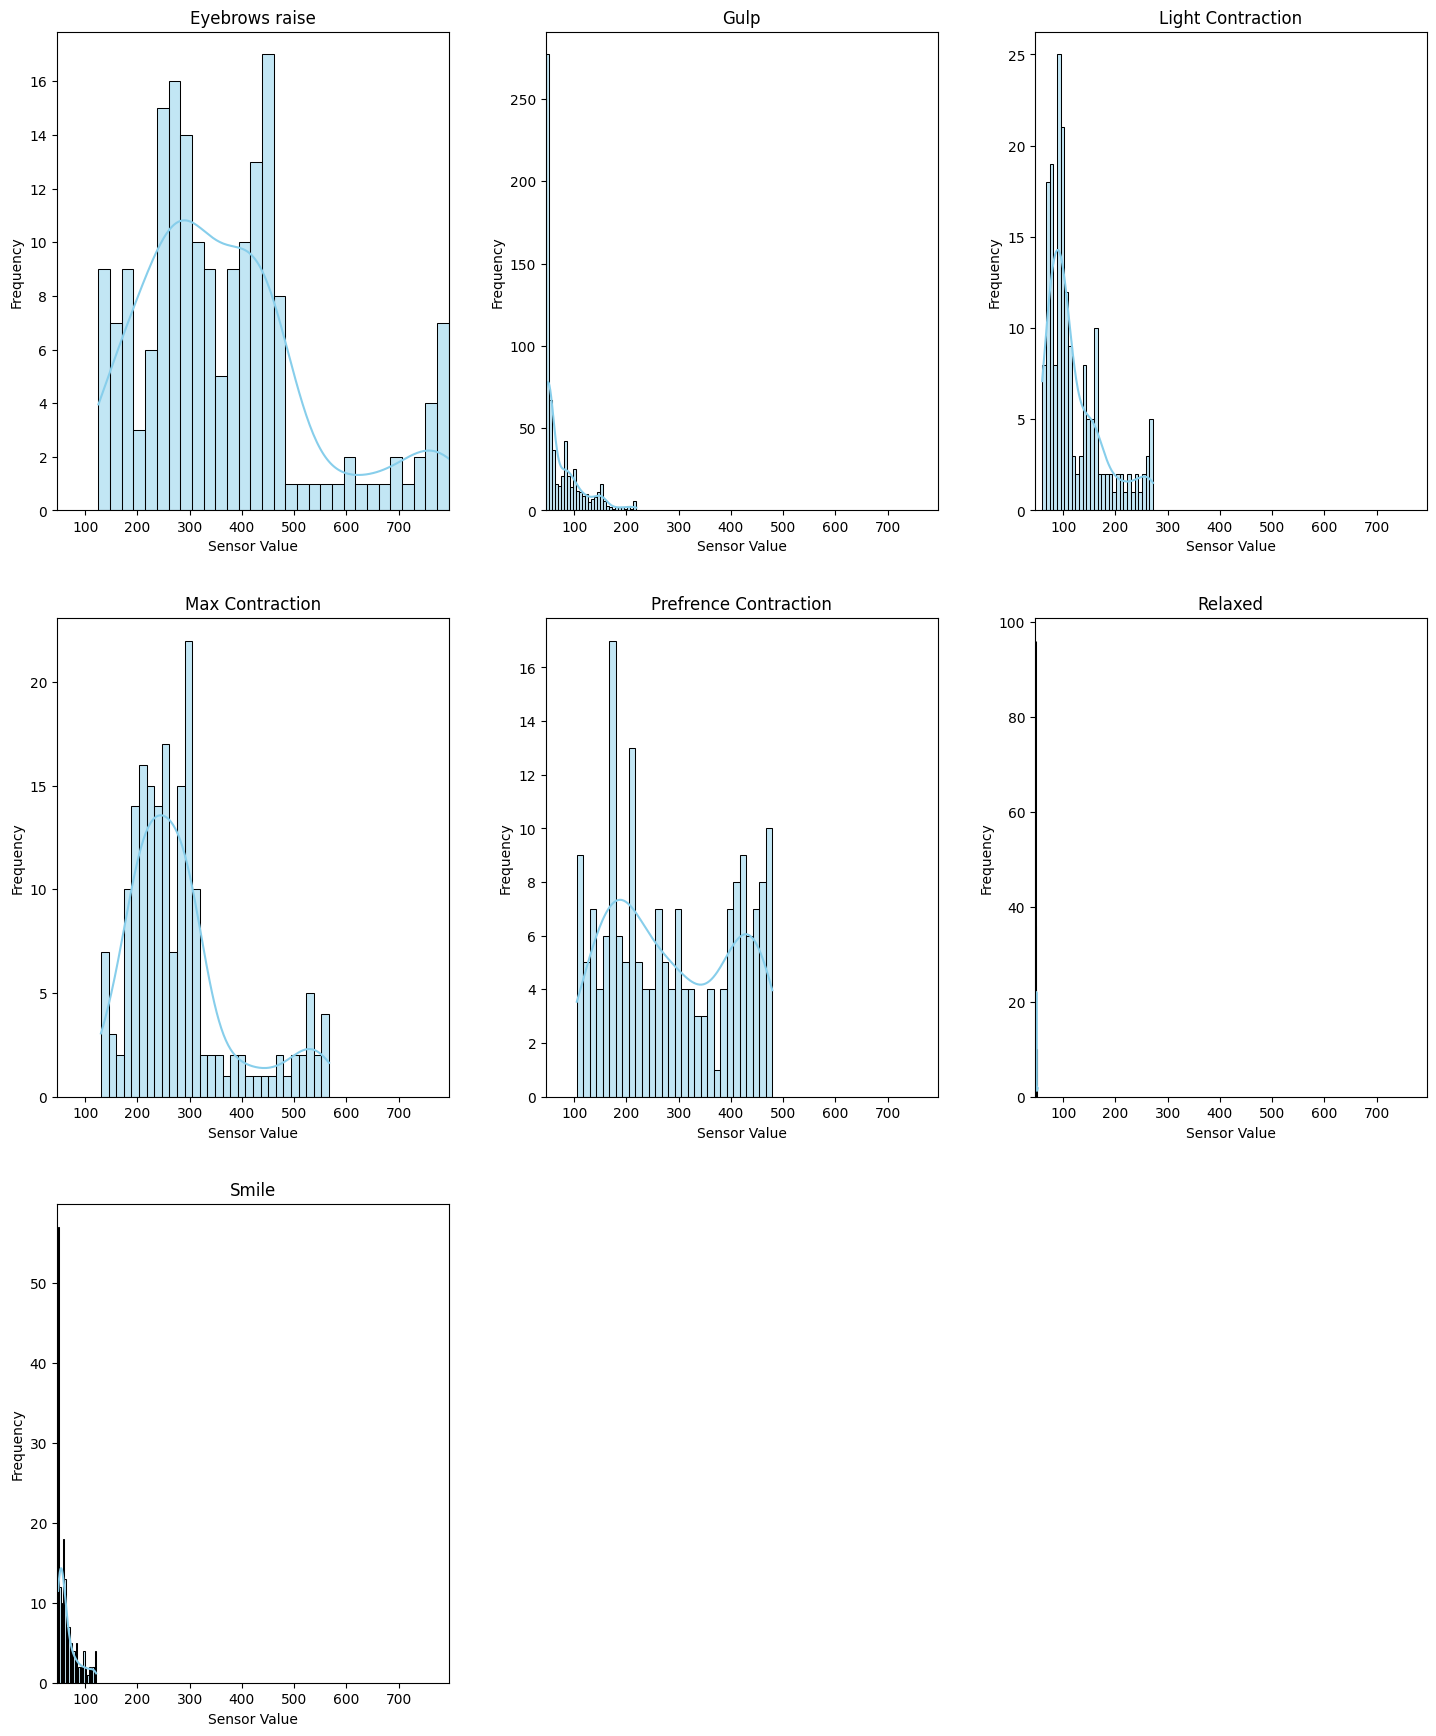

In [63]:
user_data = data[data[user_col] == target_id].copy()

if isinstance(user_data['envelope_values'].iloc[0], str):
    user_data['envelope_values'] = user_data['envelope_values'].apply(ast.literal_eval)

user_level_groups = {level: df for level, df in user_data.groupby('level_number')}

n_levels = len(user_level_groups)

if n_levels == 0:
    print(f"No data found for User ID {target_id}")
else:
    cols = 3
    rows = math.ceil(n_levels / cols)
    
    # Extract all values to find the global min and max for uniform axes
    all_values = user_data['envelope_values'].explode().astype(float)
    global_min = all_values.min()
    global_max = all_values.max()
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
    axes = axes.flatten()
    
    # Plot a histogram for each level
    for i, level in enumerate(user_level_groups):
        plot_data = user_level_groups[level]['envelope_values'].explode().astype(float)
        
        # Plot histogram with 30 bins
        sns.histplot(x=plot_data, ax=axes[i], bins=30, kde=True, color='skyblue')
        
        axes[i].set_title(f'{level}')
        axes[i].set_xlabel('Sensor Value')
        axes[i].set_ylabel('Frequency')
        
        # Set uniform x-axis limits
        axes[i].set_xlim(global_min, global_max)
    
    # Remove any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(pad=3.0)
    plt.show()


Even within one user, values tend to vary.